# Simulations light inter

In [1]:
from __future__ import annotations

import math
import os
import sys
import time as t
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

sys.path.append(".") 
from plot_outputs import *

sys.path.append("../data") 
from archi_dict import archi_sorghum as archi_1
from archi_dict import archi_maize as archi_2

# from openalea.archicrop.display import build_scene, display_scene  # noqa: F401
from openalea.archicrop.simulation import compute_extinction_coef, concat_usm
# from openalea.plantgl.all import Color3, Material, Scene  # noqa: F401


# %gui qt

In [2]:
stics_color = "orange"
archicrop_color = "green"

In [3]:
tec_file_xml='../data/usms_STICS/v10/02NT18SorgV2D1_tec.xml'
plt_file_xml='../data/usms_STICS/v10/plant/sorgho_imp_M_v10_plt.xml'
stics_output_file='../data/usms_STICS/v10/mod_s02NT18SorgV2D1.sti'
weather_file = '../data/usms_STICS/v10/ntarla_corr.2018'
location = {  
'longitude': 3.87,
'latitude': 12.58,
'altitude': 800,
'timezone': 'Europe/Paris'}

In [44]:
n = 0
file = f"../simulations_ArchiCrop/results_light_inter_{n}.nc"
ds = xr.open_dataset(file)
print(len(ds.realized_la.values[0][0][0][0]), len(ds.realized_la.values[0][0][1][0]))

89 89


In [ ]:
def open_ds(n_cpu):
    file_list = []
    for cpu in range(n_cpu):
        file_list.append(f"../simulations_ArchiCrop/results_light_inter_{cpu}.nc")
    ds = concat_usm(file_list)
    return ds


In [17]:
usms = [1,2,3,4,5,6,10,12,14,16,18] #,20,22,24,26]
usms_dict = dict(zip(range(len(usms)),usms))
n_cpu = len(usms)
ds = open_ds(n_cpu)
ds

<xarray.Dataset> Size: 417kB
Dimensions:                 (usm: 11, algo: 2, plant: 2, time: 89, id: 1)
Coordinates:
  * usm                     (usm) object 88B 'usm_1' 'usm_2' ... 'usm_18'
  * algo                    (algo) object 16B '2.5D' 'Beer'
  * plant                   (plant) object 16B 'maize' 'sorghum'
  * time                    (time) int32 356B 0 1 2 3 4 5 ... 83 84 85 86 87 88
  * id                      (id) int32 4B 1
Data variables: (12/44)
    thermal_time            (usm, algo, plant, time) float64 31kB nan ... 1.1...
    lai_stics               (usm, algo, plant, time) float64 31kB nan ... 5.0...
    sen_lai_stics           (usm, algo, plant, time) float64 31kB nan ... 1.369
    height_stics            (usm, algo, plant, time) float64 31kB nan ... 249.1
    inc_par                 (usm, algo, plant, time) float64 31kB nan ... 8.345
    abs_par_stics           (usm, algo, plant, time) float64 31kB nan ... 0.5675
    ...                      ...
    tiller_delay            (usm, algo, plant, id) int32 176B 1 1 1 1 ... 1 1 1
    reduction_factor        (usm, algo, plant, id) float64 352B 1.0 0.5 ... 0.5
    tropism_coefficient     (usm, algo, plant, id) float64 352B 0.05 ... 0.12
    leaf_lifespan           (usm, algo, plant, id) float64 352B 280.0 ... 280.0
    leaf_lifespan_early     (usm, algo, plant, id) float64 352B 224.0 ... 224.0
    domain_area             (usm, algo) float64 176B 1.28 1.28 ... 1.28 1.28

In [20]:
ds.domain_area.values[0][0]

np.float64(1.28)

In [39]:
usms_str = ds.usm.values
algos = ds.algo.values
plants = ds.plant.values
dates = ds.time.values[:-1]
# dates = pd.to_datetime(dates)
# dates = dates.strftime('%Y-%m-%d')

thermal_time = {usm: {algo: {plant: ds.thermal_time.values[u][a][p][1:] for p,plant in enumerate(plants)} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
leaf_area_plant = {usm: {algo: {plant: ds.lai_stics.values[u][a][p][1:] for p,plant in enumerate(plants)} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
sen_leaf_area_plant = {usm: {algo: {plant: ds.sen_lai_stics.values[u][a][p][1:] for p,plant in enumerate(plants)} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
height_canopy = {usm: {algo: {plant: ds.height_stics.values[u][a][p][1:] for p,plant in enumerate(plants)} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
par_incident = {usm: {algo: {plant: ds.inc_par.values[u][a][p][1:] for p,plant in enumerate(plants)} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
par_stics = {usm: {algo: {plant: ds.abs_par_stics.values[u][a][p][1:] for p,plant in enumerate(plants)} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
density = {usm: {algo: {plant: ds.density.values[u][a][p][1:] for p,plant in enumerate(plants)} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
domain_area = {usm: {algo: ds.domain_area.values[u][a] for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}

pot_la = {usm: {algo: {plant: ds.pot_la.values[u][a][p][0][:-1] for p,plant in enumerate(plants)} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
pot_h = {usm: {algo: {plant: ds.pot_h.values[u][a][p][0][:-1] for p,plant in enumerate(plants)} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
realized_la = {usm: {algo: {plant: ds.realized_la.values[u][a][p][0][:-1] for p,plant in enumerate(plants)} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}
realized_h = {usm: {algo: {plant: ds.realized_h.values[u][a][p][0][:-1] for p,plant in enumerate(plants)} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}

nrj_crop = {usm: {algo: {plant: [nrj/par_incident[usm][algo][plant][t]/domain_area[usm][algo] for t,nrj in enumerate(ds.nrj_per_leaf.values[u][a][p][0][:-1])] for p,plant in enumerate(plants)} for a,algo in enumerate(algos)} for u,usm in enumerate(usms_str)}


In [33]:
dates

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88], dtype=int32)

In [ ]:
# nrj_leaf[1][1][1][1][50]

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan])

In [ ]:
# insertion_angle = {id:i for id,i in insertion_angle.items()}
# curvature = {id:i for id,i in curvature.items()}
# nb_phy = {id:i for id,i in nb_phy.items()}

# for id,nrj in nrj_leaf.items():
#     for i,t in enumerate(nrj):
#         for j,leaf in enumerate(t):
#             if leaf == 0.0 or math.isnan(leaf):
#                 print(nrj_leaf[id][i])
#                 nrj_leaf[id][i] = t[:j]
#                 break

# nrj_crop = {id:[np.nansum([leaf for i,leaf in enumerate(t) if i < nb_phy[id]])*density for t in nrj] for id,nrj in nrj_leaf.items()}

[0.000000e+00 3.200000e-02 5.760000e-01 1.280000e+00 2.208000e+00
 3.392000e+00 4.704000e+00 6.688000e+00 9.184000e+00 1.203200e+01
 1.606400e+01 2.124800e+01 2.921600e+01 3.856000e+01 4.953600e+01
 6.614400e+01 8.476800e+01 1.035520e+02 1.312320e+02 1.585600e+02
 1.884800e+02 2.306240e+02 2.858240e+02 3.474560e+02 4.262720e+02
 5.275200e+02 6.542720e+02 7.629760e+02 9.040640e+02 1.041632e+03
 1.211296e+03 1.374432e+03 1.560864e+03 1.751584e+03 1.951808e+03
 2.161536e+03 2.401984e+03 2.613344e+03 2.854368e+03 3.114912e+03
 3.340000e+03 3.587936e+03 3.892896e+03 4.151680e+03 4.455200e+03
 4.715872e+03 4.976896e+03 5.232512e+03 5.503168e+03 5.778976e+03
 6.048320e+03 6.254016e+03 6.424640e+03 6.593600e+03 6.713600e+03
 6.586848e+03 6.478144e+03 6.337056e+03 6.198400e+03 6.027328e+03
 5.862304e+03 5.673536e+03 5.480192e+03 5.276000e+03 5.276000e+03
 5.061280e+03 4.815168e+03 4.815168e+03 4.595712e+03 4.344352e+03
 4.067840e+03 3.824064e+03 3.554176e+03 3.249248e+03 3.249248e+03
 2.957216e

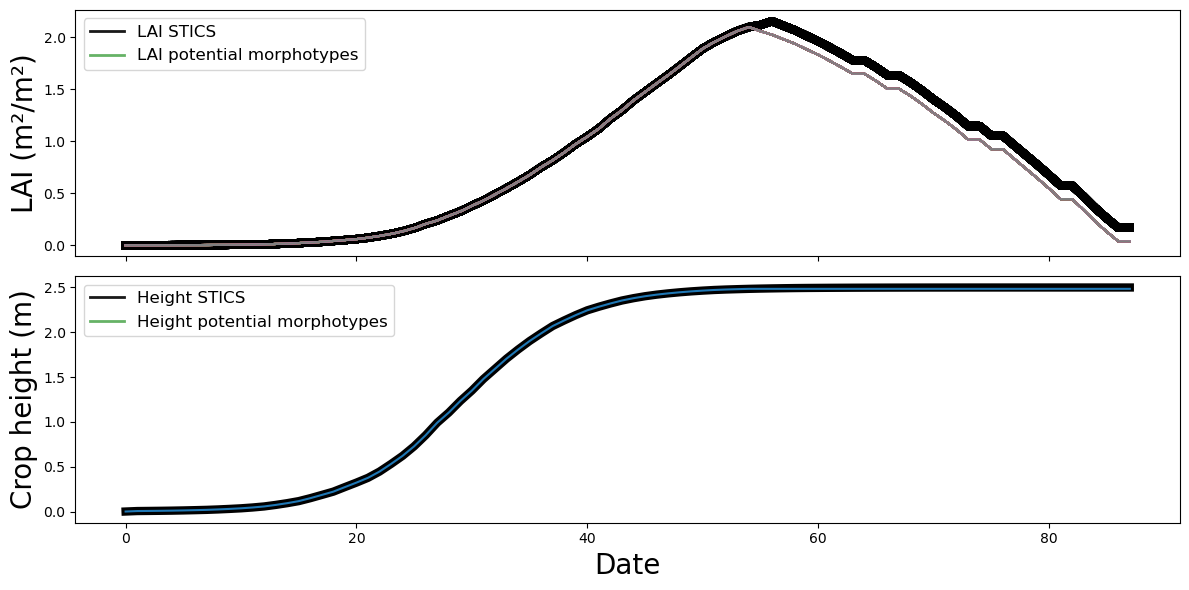

[0.0000000e+00 3.5600000e-02 6.7560000e-01 1.3512000e+00 2.2401000e+00
 3.1645000e+00 4.0889000e+00 5.3689000e+00 6.7911000e+00 8.2133000e+00
 1.0062200e+01 1.2195500e+01 1.5146600e+01 1.8204400e+01 2.1404400e+01
 2.5848800e+01 3.0293200e+01 3.4239900e+01 3.9751000e+01 4.4586600e+01
 4.9457700e+01 5.6035500e+01 6.4213300e+01 7.2711100e+01 8.3164400e+01
 9.6177700e+01 1.1199990e+02 1.2455100e+02 1.4108430e+02 1.5683540e+02
 1.7795540e+02 1.9850650e+02 2.2335980e+02 2.4967090e+02 2.7982200e+02
 3.1320870e+02 3.5470200e+02 3.9249760e+02 4.3967980e+02 4.9599980e+02
 5.4702200e+02 6.0831980e+02 6.8433760e+02 7.6113760e+02 8.4682650e+02
 9.3567980e+02 9.7077310e+02 1.0422042e+03 1.0834842e+03 1.1665775e+03
 1.2427019e+03 1.2961775e+03 1.3580797e+03 1.4299375e+03 1.4773331e+03
 1.4773331e+03 1.4773331e+03 1.4773331e+03 1.4773331e+03 1.4773331e+03
 1.4773331e+03 1.4773331e+03 1.4773331e+03 1.4773331e+03 1.4773331e+03
 1.4773331e+03 1.4773331e+03 1.4773331e+03 1.4773331e+03 1.4773331e+03
 1.477

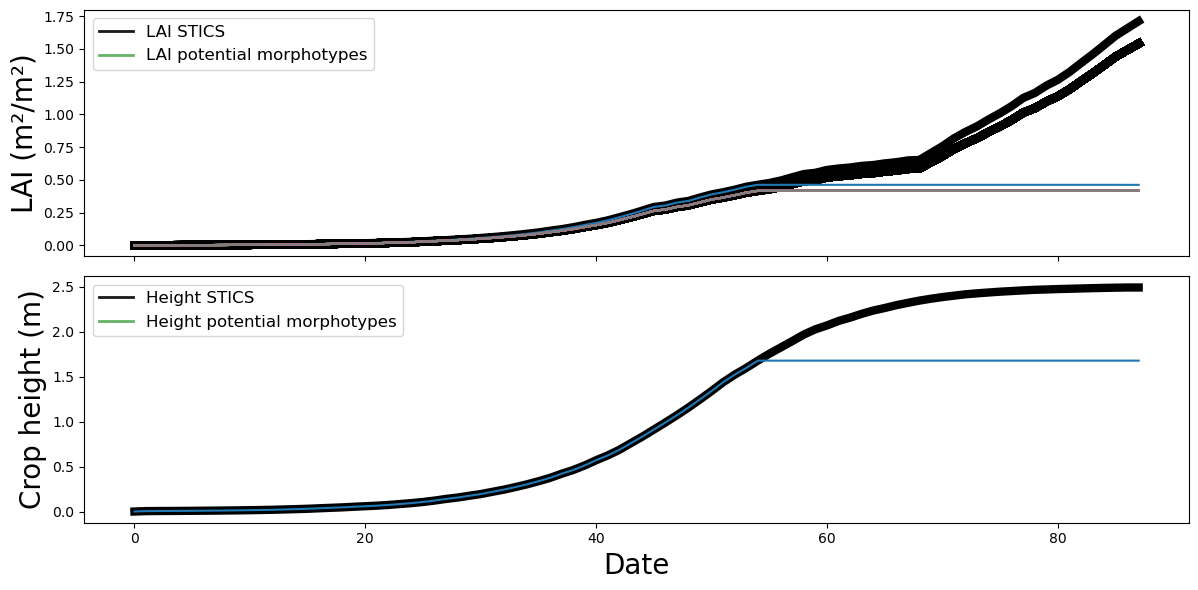

[0.000000e+00 3.200000e-02 5.760000e-01 1.280000e+00 2.208000e+00
 3.392000e+00 4.704000e+00 6.688000e+00 9.184000e+00 1.203200e+01
 1.606400e+01 2.121600e+01 2.921600e+01 3.856000e+01 4.956800e+01
 6.617600e+01 8.480000e+01 1.036160e+02 1.313600e+02 1.587200e+02
 1.886400e+02 2.309120e+02 2.861760e+02 3.478720e+02 4.268800e+02
 5.278400e+02 6.548160e+02 7.635840e+02 9.048320e+02 1.042496e+03
 1.212192e+03 1.375392e+03 1.561792e+03 1.752480e+03 1.952640e+03
 2.162272e+03 2.402560e+03 2.613952e+03 2.854848e+03 3.115168e+03
 3.340032e+03 3.587744e+03 3.892384e+03 4.150848e+03 4.454016e+03
 4.714336e+03 4.975264e+03 5.230176e+03 5.500384e+03 5.775584e+03
 6.043872e+03 6.248704e+03 6.418432e+03 6.586368e+03 6.705952e+03
 6.578976e+03 6.470208e+03 6.328960e+03 6.190208e+03 6.019104e+03
 5.854048e+03 5.665248e+03 5.471968e+03 5.267808e+03 5.267808e+03
 5.053216e+03 5.053216e+03 4.807232e+03 4.587776e+03 4.336544e+03
 4.060256e+03 3.816672e+03 3.546976e+03 3.546976e+03 3.242336e+03
 2.950656e

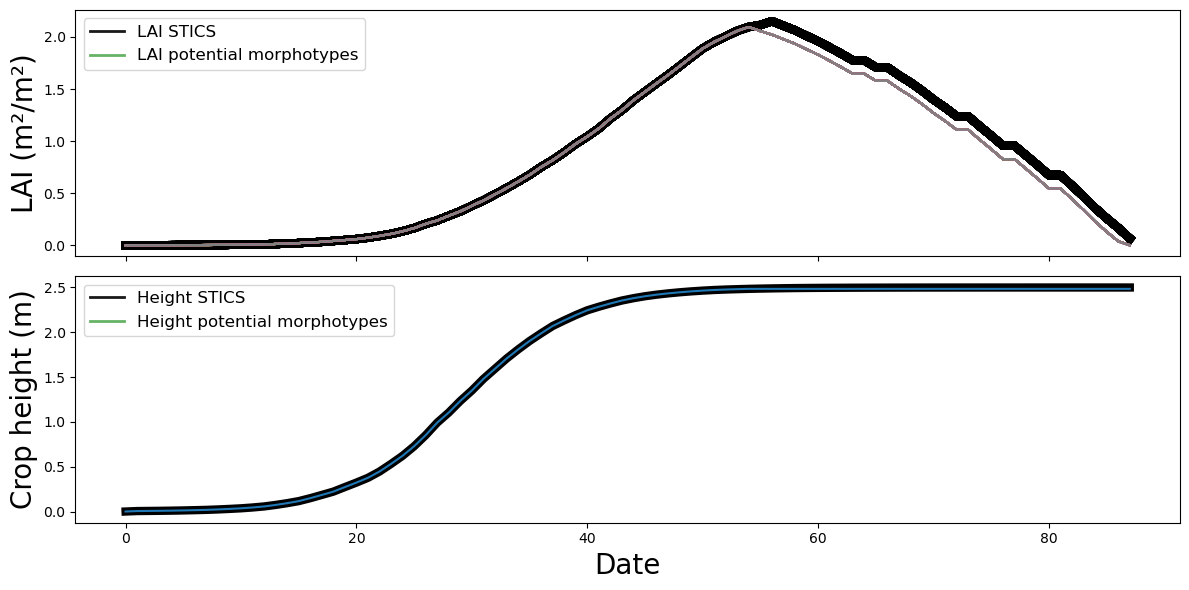

[0.0000000e+00 3.5600000e-02 6.7560000e-01 1.3512000e+00 2.2401000e+00
 3.1645000e+00 4.0889000e+00 5.3689000e+00 6.7911000e+00 8.2133000e+00
 1.0062200e+01 1.2160000e+01 1.5146700e+01 1.8204500e+01 2.1404500e+01
 2.5848900e+01 3.0293300e+01 3.4240000e+01 3.9786700e+01 4.4622300e+01
 4.9493400e+01 5.6071200e+01 6.4284500e+01 7.2782300e+01 8.3271200e+01
 9.6213400e+01 1.1210670e+02 1.2465780e+02 1.4122670e+02 1.5694230e+02
 1.7809790e+02 1.9868460e+02 2.2353790e+02 2.4988460e+02 2.8003570e+02
 3.1342240e+02 3.5491570e+02 3.9274680e+02 4.3989350e+02 4.9621350e+02
 5.4716460e+02 6.0846240e+02 6.8437350e+02 7.6110240e+02 8.4668460e+02
 9.3539570e+02 9.9861350e+02 1.0974935e+03 1.1843913e+03 1.2998046e+03
 1.4265957e+03 1.5406935e+03 1.6477513e+03 1.7729069e+03 1.8993069e+03
 1.8993069e+03 1.8993069e+03 1.8993069e+03 1.8993069e+03 1.8993069e+03
 1.8993069e+03 1.8993069e+03 1.8993069e+03 1.8993069e+03 1.8993069e+03
 1.8993069e+03 1.8993069e+03 1.8993069e+03 1.8993069e+03 1.8993069e+03
 1.899

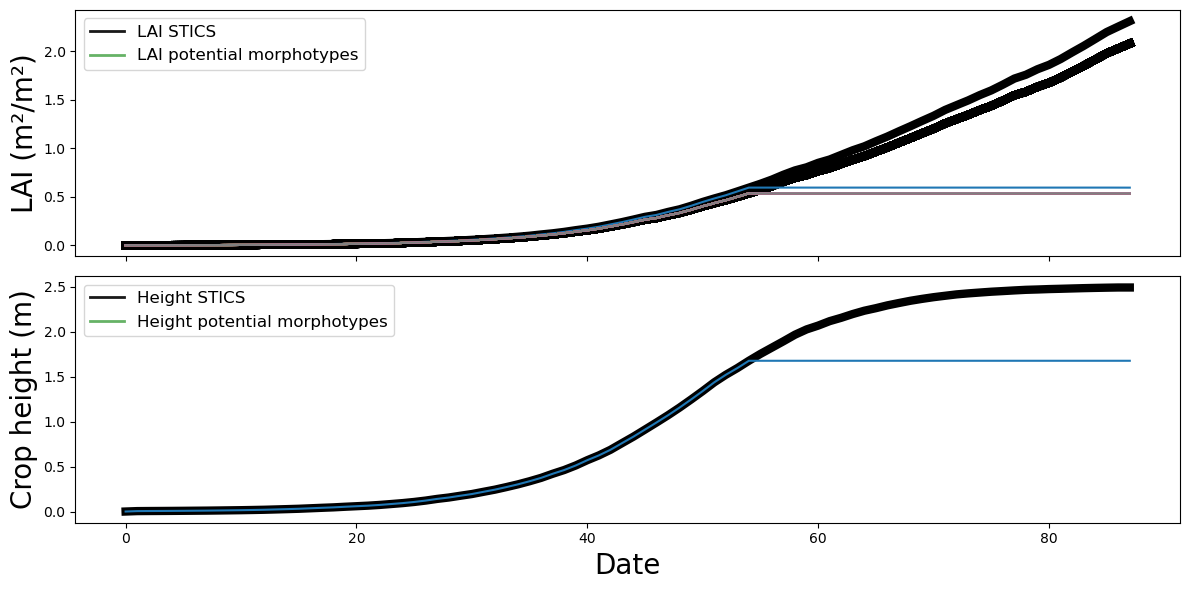

[0.000000e+00 3.200000e-02 5.760000e-01 1.264000e+00 2.208000e+00
 3.408000e+00 4.720000e+00 6.704000e+00 9.200000e+00 1.203200e+01
 1.608000e+01 2.124800e+01 2.920000e+01 3.851200e+01 4.945600e+01
 6.600000e+01 8.462400e+01 1.033920e+02 1.308320e+02 1.581120e+02
 1.879360e+02 2.301120e+02 2.852160e+02 3.467360e+02 4.258720e+02
 5.258080e+02 6.528640e+02 7.613920e+02 9.031200e+02 1.026176e+03
 1.178960e+03 1.325792e+03 1.493872e+03 1.666048e+03 1.851776e+03
 2.045840e+03 2.268672e+03 2.463856e+03 2.686688e+03 2.927632e+03
 3.135136e+03 3.363648e+03 3.646704e+03 3.884800e+03 4.128832e+03
 4.404976e+03 4.644496e+03 4.877808e+03 5.124128e+03 5.375552e+03
 5.619200e+03 5.801696e+03 5.950544e+03 6.094832e+03 6.193424e+03
 6.066368e+03 5.957840e+03 5.816128e+03 5.691984e+03 5.537808e+03
 5.389072e+03 5.218608e+03 5.043808e+03 4.854112e+03 4.655056e+03
 4.426560e+03 4.223296e+03 4.223296e+03 4.223296e+03 3.990112e+03
 3.733264e+03 3.507136e+03 3.256736e+03 2.973680e+03 2.973680e+03
 2.702512e

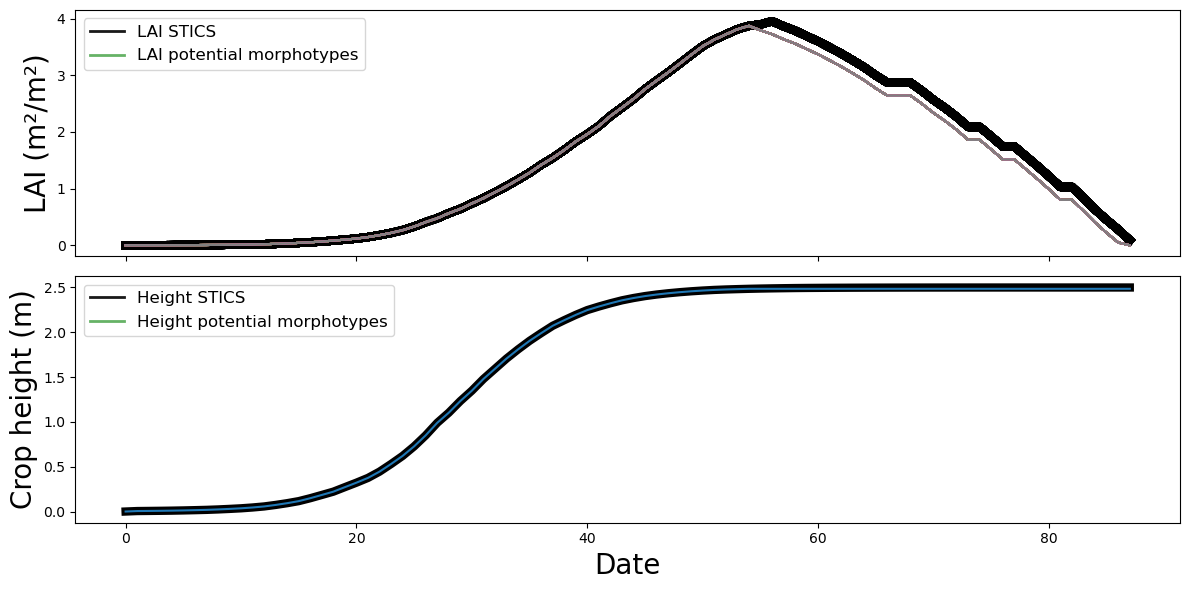

[0.000000e+00 3.560000e-02 6.578000e-01 1.368900e+00 2.222200e+00
 3.182200e+00 4.106600e+00 5.368800e+00 6.791000e+00 8.213200e+00
 1.006210e+01 1.217770e+01 1.512880e+01 1.818660e+01 2.136880e+01
 2.579550e+01 3.023990e+01 3.420430e+01 3.966210e+01 4.449770e+01
 4.933330e+01 5.592890e+01 6.410670e+01 7.260450e+01 8.309340e+01
 9.589340e+01 1.118045e+02 1.243378e+02 1.409600e+02 1.566756e+02
 1.779556e+02 1.986667e+02 2.237511e+02 2.432178e+02 2.655289e+02
 2.901867e+02 3.209067e+02 3.488178e+02 3.837334e+02 4.255290e+02
 4.633246e+02 5.087824e+02 5.651913e+02 6.222757e+02 6.857957e+02
 7.516801e+02 7.632001e+02 7.847645e+02 7.957689e+02 8.175645e+02
 8.355912e+02 8.467734e+02 8.590756e+02 8.727823e+02 8.807645e+02
 8.807645e+02 8.807645e+02 8.807645e+02 8.807645e+02 8.807645e+02
 8.807645e+02 8.807645e+02 8.807645e+02 8.807645e+02 8.807645e+02
 8.807645e+02 8.807645e+02 8.807645e+02 8.807645e+02 8.807645e+02
 8.807645e+02 8.807645e+02 8.807645e+02 8.807645e+02 8.807645e+02
 8.807645e

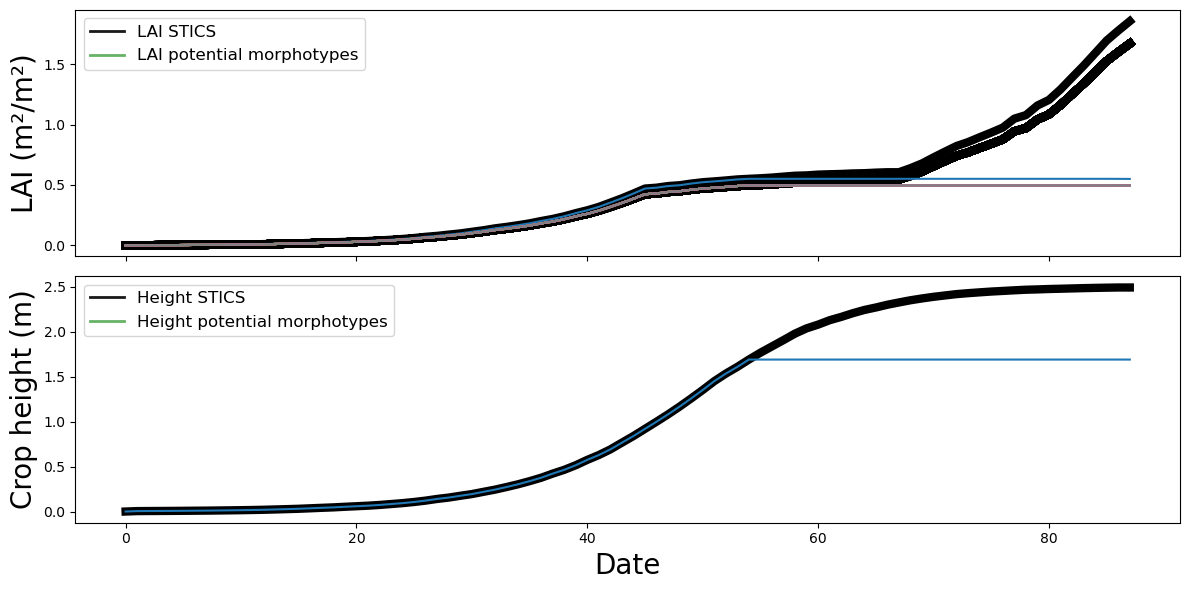

[0.000000e+00 3.200000e-02 5.760000e-01 1.264000e+00 2.208000e+00
 3.408000e+00 4.720000e+00 6.704000e+00 9.200000e+00 1.201600e+01
 1.606400e+01 2.123200e+01 2.921600e+01 3.854400e+01 4.950400e+01
 6.609600e+01 8.472000e+01 1.035040e+02 1.310880e+02 1.584160e+02
 1.882880e+02 2.306560e+02 2.858720e+02 3.475040e+02 4.269760e+02
 5.268000e+02 6.542560e+02 7.630080e+02 9.050400e+02 1.028272e+03
 1.181120e+03 1.327968e+03 1.496016e+03 1.668096e+03 1.853648e+03
 2.047488e+03 2.269984e+03 2.464880e+03 2.687360e+03 2.927744e+03
 3.134784e+03 3.362736e+03 3.645072e+03 3.882336e+03 4.125648e+03
 4.401008e+03 4.639568e+03 4.871584e+03 5.117024e+03 5.367232e+03
 5.609120e+03 5.790224e+03 5.938000e+03 6.080208e+03 6.177696e+03
 6.050240e+03 5.941504e+03 5.799456e+03 5.675136e+03 5.520912e+03
 5.372160e+03 5.201744e+03 5.027024e+03 4.837504e+03 4.638688e+03
 4.410528e+03 4.410528e+03 4.410528e+03 4.207536e+03 3.974736e+03
 3.718384e+03 3.492688e+03 3.242816e+03 2.960480e+03 2.960480e+03
 2.690032e

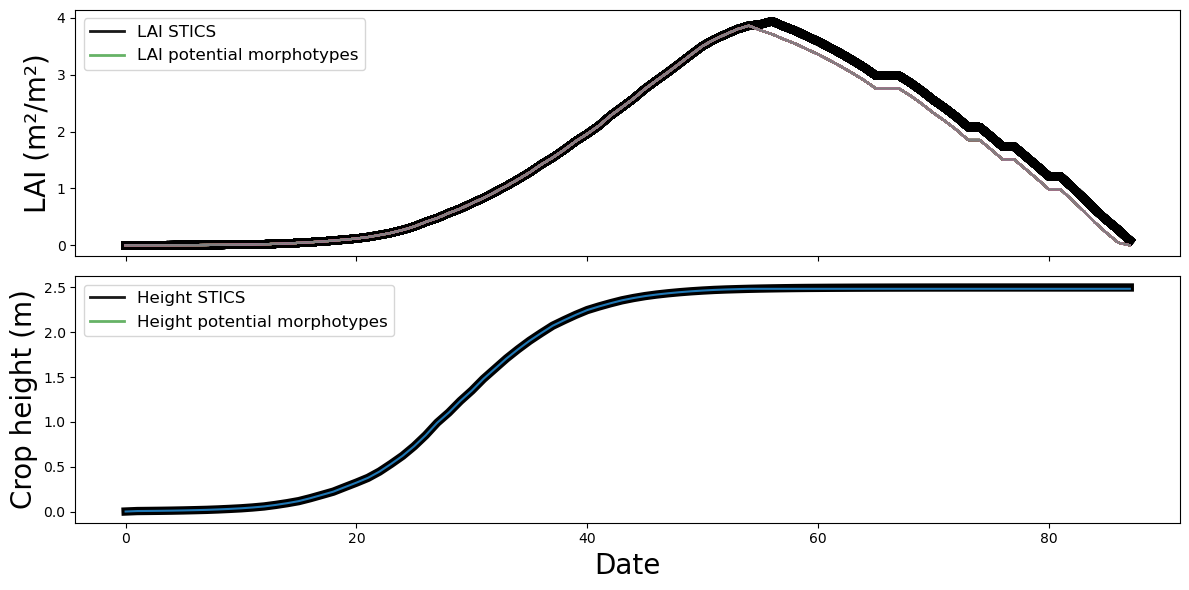

[0.0000000e+00 3.5600000e-02 6.5780000e-01 1.3689000e+00 2.2222000e+00
 3.1822000e+00 4.1066000e+00 5.3688000e+00 6.7910000e+00 8.2132000e+00
 1.0062100e+01 1.2177700e+01 1.5146600e+01 1.8186600e+01 2.1386600e+01
 2.5831000e+01 3.0275400e+01 3.4222100e+01 3.9715400e+01 4.4551000e+01
 4.9404300e+01 5.6035400e+01 6.4231000e+01 7.2728800e+01 8.3271000e+01
 9.6053200e+01 1.1201760e+02 1.2456870e+02 1.4124430e+02 1.5697760e+02
 1.7831090e+02 1.9905760e+02 2.2417760e+02 2.4366200e+02 2.6597310e+02
 2.9064870e+02 3.2135090e+02 3.4924420e+02 3.8412420e+02 4.2586640e+02
 4.6359080e+02 5.0895970e+02 5.6522640e+02 6.2211530e+02 6.8542200e+02
 7.5105760e+02 7.8559980e+02 8.5822200e+02 9.0391090e+02 9.8871090e+02
 1.0748442e+03 1.1389331e+03 1.2145953e+03 1.3038220e+03 1.3665420e+03
 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03
 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03
 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03
 1.366

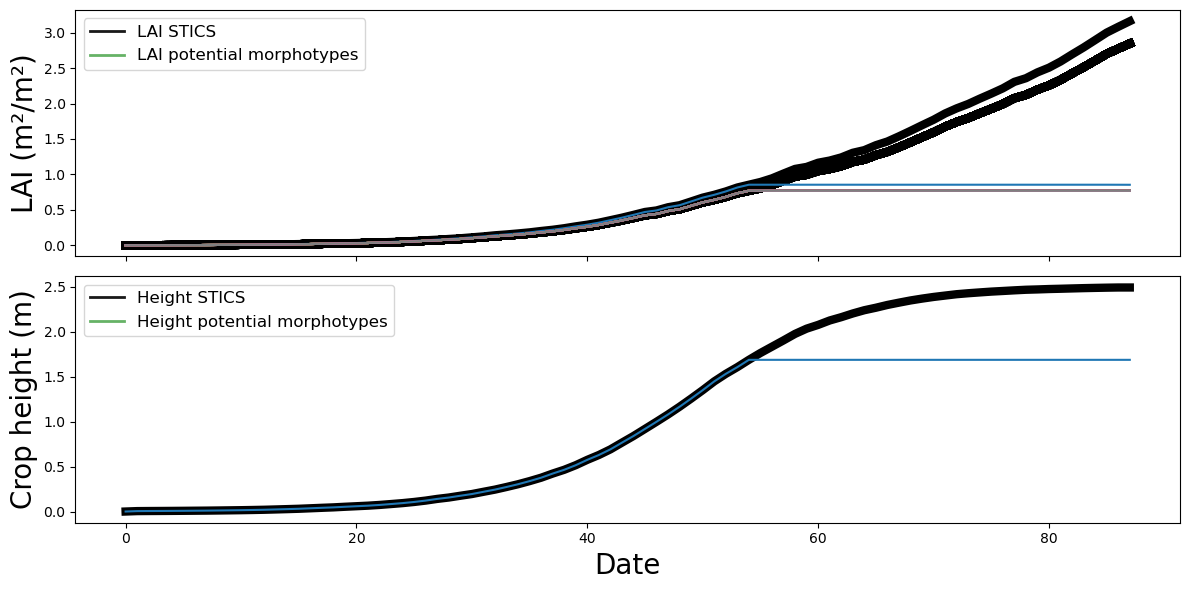

[0.000000e+00 2.400000e-02 5.760000e-01 1.264000e+00 2.216000e+00
 3.408000e+00 4.720000e+00 6.704000e+00 9.200000e+00 1.203200e+01
 1.608000e+01 2.124800e+01 2.911200e+01 3.838400e+01 4.918400e+01
 6.524800e+01 8.367200e+01 1.022560e+02 1.289360e+02 1.558800e+02
 1.853520e+02 2.272160e+02 2.818320e+02 3.427280e+02 4.218720e+02
 5.035040e+02 6.081840e+02 6.977440e+02 8.148560e+02 9.276800e+02
 1.069248e+03 1.205112e+03 1.360960e+03 1.520920e+03 1.693232e+03
 1.872768e+03 2.079144e+03 2.259336e+03 2.465264e+03 2.687440e+03
 2.878312e+03 3.088344e+03 3.350680e+03 3.569296e+03 3.829360e+03
 4.047472e+03 4.266344e+03 4.479200e+03 4.702488e+03 4.930496e+03
 5.149176e+03 5.309696e+03 5.438368e+03 5.558680e+03 5.670240e+03
 5.565560e+03 5.476000e+03 5.358888e+03 5.244960e+03 5.102016e+03
 4.964256e+03 4.806016e+03 4.643432e+03 4.467160e+03 4.282624e+03
 4.070584e+03 3.882296e+03 3.666032e+03 3.428128e+03 3.428128e+03
 3.428128e+03 3.218712e+03 2.987080e+03 2.987080e+03 2.724736e+03
 2.473992e

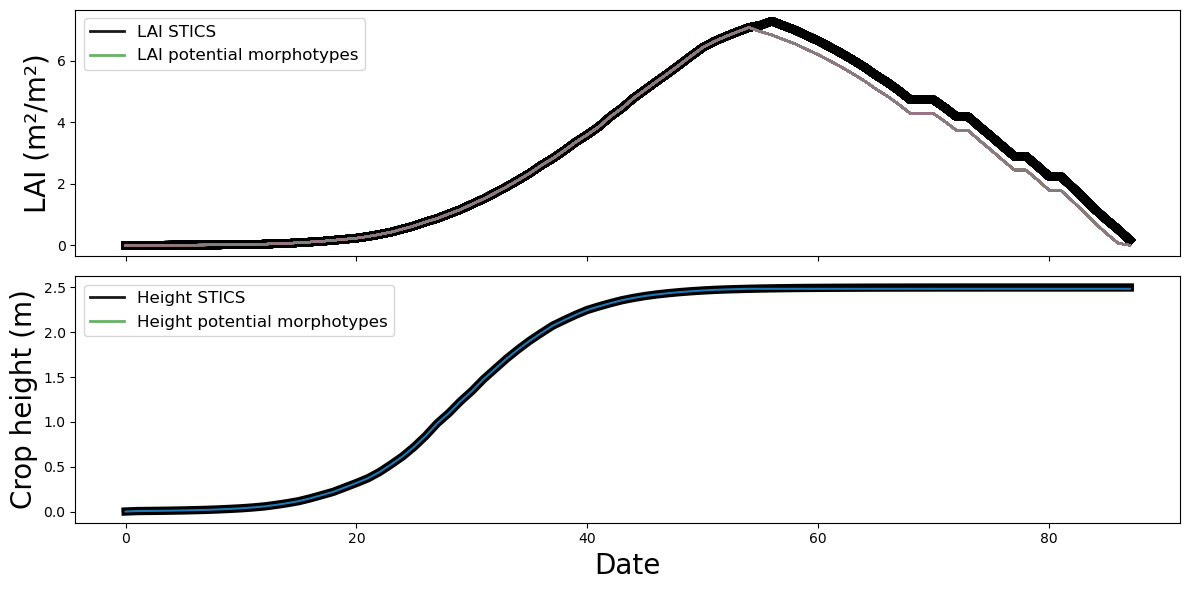

[0.000000e+00 4.440000e-02 6.666000e-01 1.368800e+00 2.222100e+00
 3.182100e+00 4.106500e+00 5.377600e+00 6.799800e+00 8.222000e+00
 1.007090e+01 1.218650e+01 1.510210e+01 1.813320e+01 2.128880e+01
 2.558210e+01 2.998210e+01 3.391100e+01 3.922660e+01 4.401770e+01
 4.880880e+01 5.538660e+01 6.351100e+01 7.191990e+01 8.244430e+01
 9.514650e+01 1.110576e+02 1.236087e+02 1.322220e+02 1.403109e+02
 1.513687e+02 1.621243e+02 1.751821e+02 1.890932e+02 2.050399e+02
 2.226221e+02 2.445688e+02 2.644799e+02 2.894310e+02 3.192710e+02
 3.462666e+02 3.787022e+02 4.190578e+02 4.597867e+02 5.051111e+02
 5.520533e+02 5.540444e+02 5.574311e+02 5.587378e+02 5.620711e+02
 5.645955e+02 5.658133e+02 5.672444e+02 5.690044e+02 5.697155e+02
 5.697155e+02 5.697155e+02 5.697155e+02 5.697155e+02 5.697155e+02
 5.697155e+02 5.697155e+02 5.697155e+02 5.697155e+02 5.697155e+02
 5.697155e+02 5.697155e+02 5.697155e+02 5.697155e+02 5.697155e+02
 5.697155e+02 5.697155e+02 5.697155e+02 5.697155e+02 5.697155e+02
 5.697155e

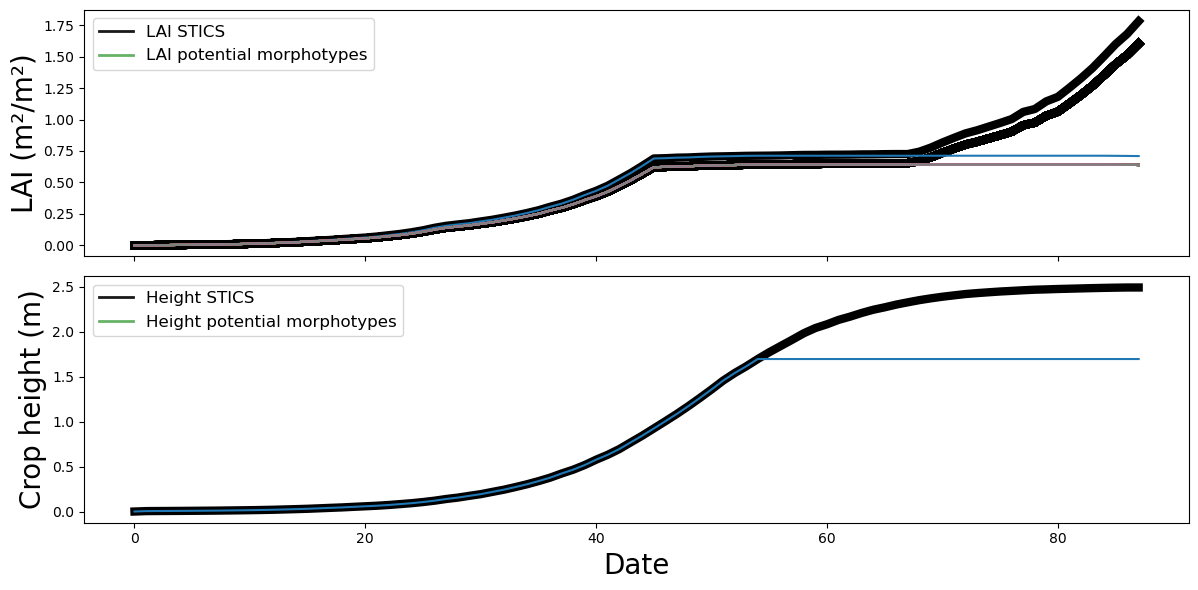

[0.000000e+00 2.400000e-02 5.760000e-01 1.264000e+00 2.216000e+00
 3.408000e+00 4.720000e+00 6.704000e+00 9.200000e+00 1.202400e+01
 1.607200e+01 2.124800e+01 2.918400e+01 3.849600e+01 4.942400e+01
 6.589600e+01 8.456000e+01 1.033120e+02 1.305920e+02 1.578240e+02
 1.876000e+02 2.301440e+02 2.856160e+02 3.471920e+02 4.274880e+02
 5.102160e+02 6.161840e+02 7.067600e+02 8.250240e+02 9.388480e+02
 1.080384e+03 1.216184e+03 1.371856e+03 1.531520e+03 1.703464e+03
 1.882560e+03 2.088344e+03 2.268056e+03 2.473288e+03 2.694832e+03
 2.884992e+03 3.094232e+03 3.322592e+03 3.572664e+03 3.794440e+03
 4.048672e+03 4.266056e+03 4.476504e+03 4.670552e+03 4.896784e+03
 5.112792e+03 5.270496e+03 5.397072e+03 5.513880e+03 5.622152e+03
 5.678448e+03 5.587872e+03 5.469608e+03 5.354680e+03 5.211768e+03
 5.074072e+03 4.916016e+03 4.753720e+03 4.577816e+03 4.393728e+03
 4.182280e+03 3.994480e+03 3.994480e+03 3.778896e+03 3.541480e+03
 3.541480e+03 3.541480e+03 3.332696e+03 3.101600e+03 2.840296e+03
 2.590224e

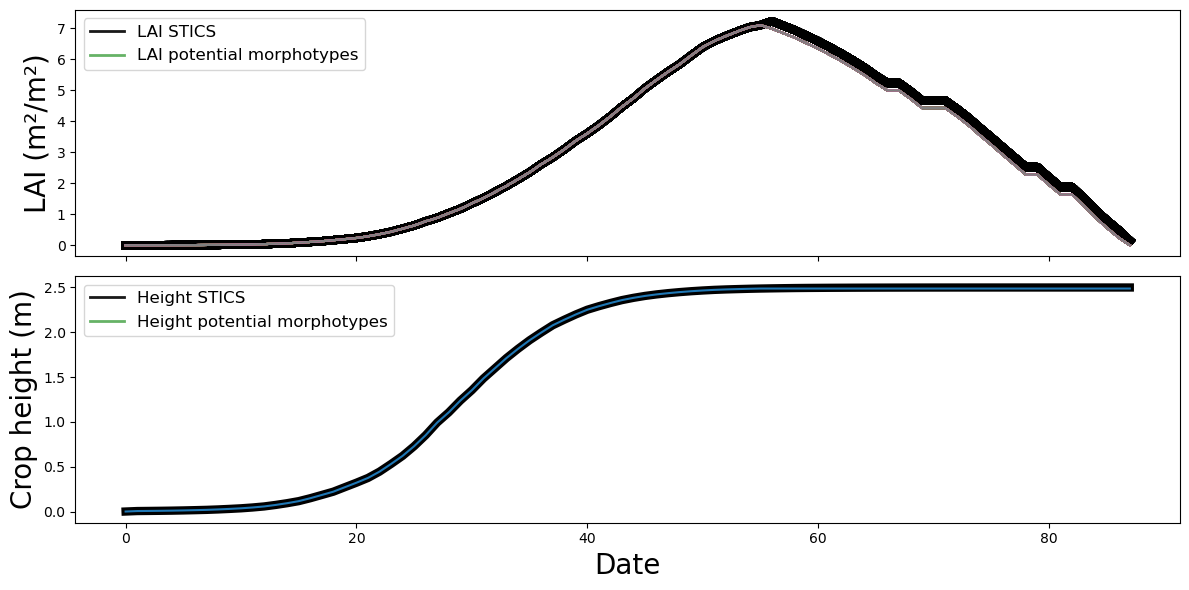

[0.000000e+00 4.440000e-02 6.666000e-01 1.368800e+00 2.222100e+00
 3.182100e+00 4.106500e+00 5.377600e+00 6.799800e+00 8.222000e+00
 1.007090e+01 1.218650e+01 1.512870e+01 1.817760e+01 2.135980e+01
 2.577760e+01 3.022200e+01 3.417760e+01 3.959980e+01 4.443540e+01
 4.926210e+01 5.593770e+01 6.417770e+01 7.266660e+01 8.334220e+01
 9.620440e+01 1.123200e+02 1.250222e+02 1.337333e+02 1.419111e+02
 1.530755e+02 1.639288e+02 1.771021e+02 1.911199e+02 2.071643e+02
 2.248532e+02 2.469065e+02 2.669154e+02 2.919554e+02 3.219287e+02
 3.490043e+02 3.815465e+02 4.219198e+02 4.627198e+02 5.080354e+02
 5.549954e+02 5.708176e+02 6.040532e+02 6.235288e+02 6.616888e+02
 6.966932e+02 7.217954e+02 7.507998e+02 7.843198e+02 8.071465e+02
 8.071465e+02 8.071465e+02 8.071465e+02 8.071465e+02 8.071465e+02
 8.071465e+02 8.071465e+02 8.071465e+02 8.071465e+02 8.071465e+02
 8.071465e+02 8.071465e+02 8.071465e+02 8.071465e+02 8.071465e+02
 8.071465e+02 8.071465e+02 8.071465e+02 8.071465e+02 8.071465e+02
 8.071465e

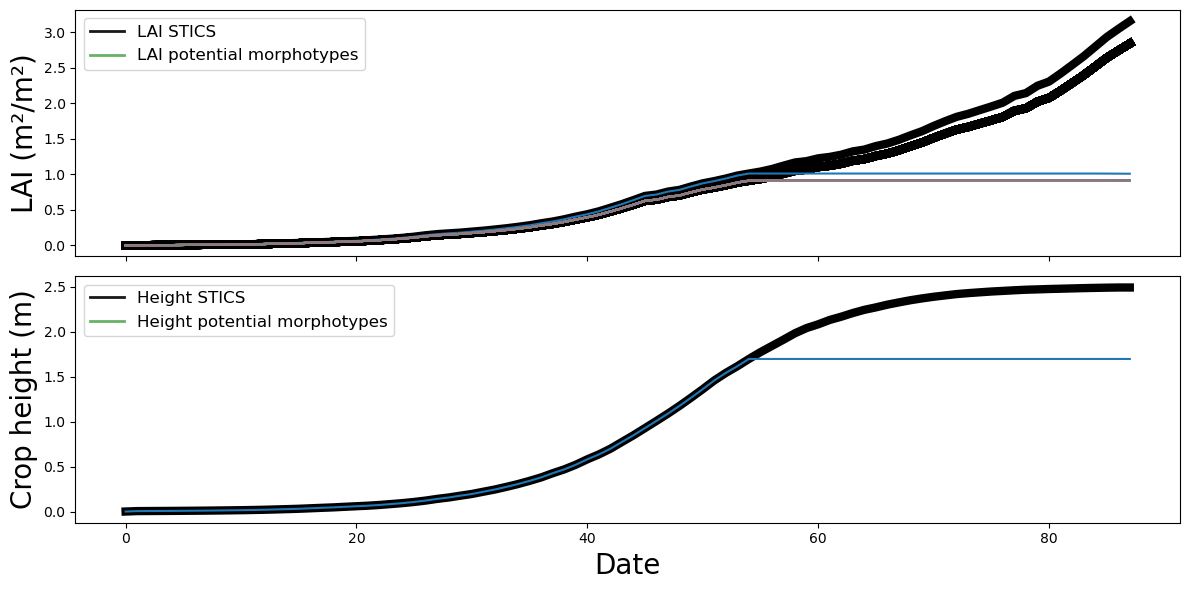

[0.000000e+00 3.200000e-02 5.760000e-01 1.280000e+00 2.208000e+00
 3.392000e+00 4.704000e+00 6.688000e+00 9.184000e+00 1.203200e+01
 1.606400e+01 2.124800e+01 2.921600e+01 3.856000e+01 4.953600e+01
 6.614400e+01 8.476800e+01 1.035520e+02 1.312320e+02 1.585600e+02
 1.884800e+02 2.305280e+02 2.857280e+02 3.473280e+02 4.259200e+02
 5.274880e+02 6.537600e+02 7.624000e+02 9.033280e+02 1.040832e+03
 1.209824e+03 1.372832e+03 1.558528e+03 1.748352e+03 1.947776e+03
 2.156640e+03 2.396064e+03 2.607296e+03 2.847296e+03 3.106752e+03
 3.331264e+03 3.578176e+03 3.881888e+03 4.139520e+03 4.441952e+03
 4.701504e+03 4.999200e+03 5.271264e+03 5.540256e+03 5.819936e+03
 6.112544e+03 6.343232e+03 6.525376e+03 6.727584e+03 6.891680e+03
 7.003392e+03 6.877152e+03 6.768480e+03 6.627552e+03 6.488960e+03
 6.318592e+03 6.153696e+03 5.965632e+03 5.773152e+03 5.569760e+03
 5.355936e+03 5.110816e+03 4.891520e+03 4.641184e+03 4.365760e+03
 4.122592e+03 3.853696e+03 3.549984e+03 3.259136e+03 2.956704e+03
 2.659904e

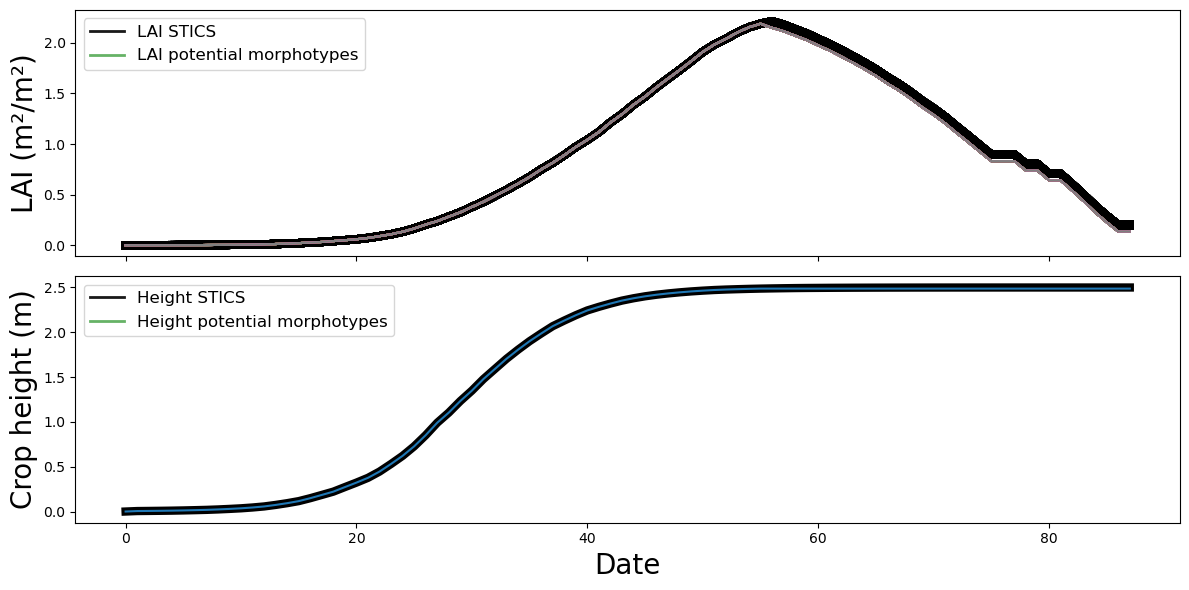

[0.0000000e+00 3.5600000e-02 6.7560000e-01 1.3512000e+00 2.2401000e+00
 3.1645000e+00 4.0889000e+00 5.3689000e+00 6.7911000e+00 8.2133000e+00
 1.0062200e+01 1.2195500e+01 1.5146600e+01 1.8204400e+01 2.1404400e+01
 2.5848800e+01 3.0293200e+01 3.4239900e+01 3.9751000e+01 4.4586600e+01
 4.9457700e+01 5.5999900e+01 6.4213200e+01 7.2711000e+01 8.3093200e+01
 9.6142100e+01 1.1192880e+02 1.2447990e+02 1.4097770e+02 1.5669330e+02
 1.7770660e+02 1.9822220e+02 2.2293330e+02 2.4906660e+02 2.7900440e+02
 3.1214220e+02 3.5335110e+02 3.9104000e+02 4.3783110e+02 4.9376000e+02
 5.4446220e+02 6.0529780e+02 6.8071110e+02 7.5690670e+02 8.4192000e+02
 9.3006220e+02 9.5413330e+02 1.0054400e+03 1.0370133e+03 1.1024711e+03
 1.1655111e+03 1.2132622e+03 1.2710044e+03 1.3400533e+03 1.3893333e+03
 1.3893333e+03 1.3893333e+03 1.3893333e+03 1.3893333e+03 1.3893333e+03
 1.3893333e+03 1.3893333e+03 1.3893333e+03 1.3893333e+03 1.3893333e+03
 1.3893333e+03 1.3893333e+03 1.3893333e+03 1.3893333e+03 1.3893333e+03
 1.389

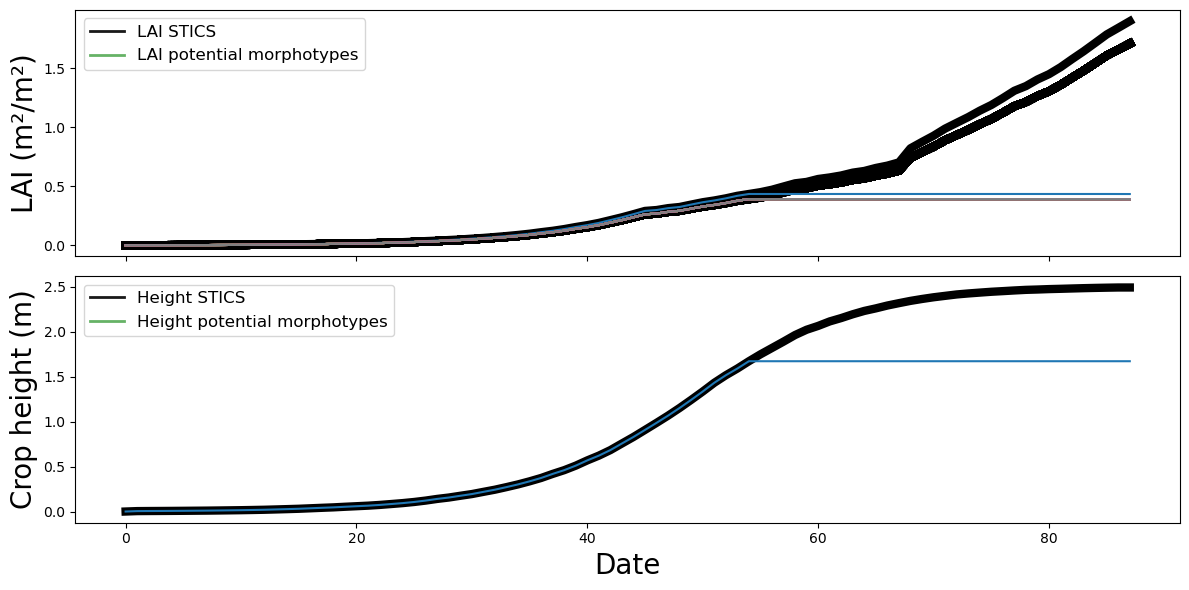

[0.000000e+00 3.200000e-02 5.760000e-01 1.280000e+00 2.208000e+00
 3.392000e+00 4.704000e+00 6.688000e+00 9.184000e+00 1.203200e+01
 1.606400e+01 2.121600e+01 2.921600e+01 3.856000e+01 4.956800e+01
 6.617600e+01 8.480000e+01 1.036160e+02 1.313600e+02 1.587200e+02
 1.886400e+02 2.309120e+02 2.861760e+02 3.478720e+02 4.268800e+02
 5.278400e+02 6.548160e+02 7.635840e+02 9.048320e+02 1.042496e+03
 1.212192e+03 1.375392e+03 1.561792e+03 1.752480e+03 1.952640e+03
 2.162272e+03 2.402560e+03 2.613952e+03 2.854848e+03 3.115168e+03
 3.340032e+03 3.587744e+03 3.892384e+03 4.150848e+03 4.454016e+03
 4.714336e+03 4.975264e+03 5.230176e+03 5.500384e+03 5.775584e+03
 6.043872e+03 6.248704e+03 6.418432e+03 6.586368e+03 6.705952e+03
 6.578976e+03 6.470208e+03 6.328960e+03 6.190208e+03 6.019104e+03
 5.854048e+03 5.665248e+03 5.471968e+03 5.267808e+03 5.267808e+03
 5.053216e+03 5.053216e+03 4.807232e+03 4.587776e+03 4.336544e+03
 4.060256e+03 3.816672e+03 3.546976e+03 3.546976e+03 3.242336e+03
 2.950656e

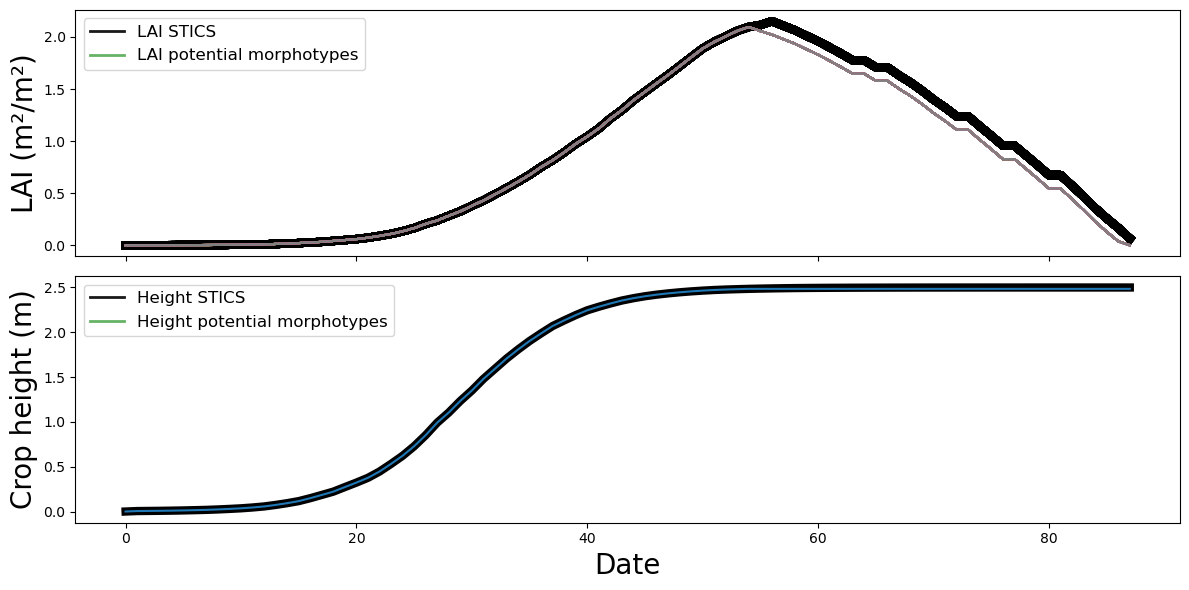

[0.0000000e+00 3.5600000e-02 6.7560000e-01 1.3512000e+00 2.2401000e+00
 3.1645000e+00 4.0889000e+00 5.3689000e+00 6.7911000e+00 8.2133000e+00
 1.0062200e+01 1.2160000e+01 1.5146700e+01 1.8204500e+01 2.1404500e+01
 2.5848900e+01 3.0293300e+01 3.4240000e+01 3.9786700e+01 4.4622300e+01
 4.9493400e+01 5.6071200e+01 6.4284500e+01 7.2782300e+01 8.3271200e+01
 9.6213400e+01 1.1210670e+02 1.2465780e+02 1.4122670e+02 1.5694230e+02
 1.7809790e+02 1.9868460e+02 2.2353790e+02 2.4988460e+02 2.8003570e+02
 3.1342240e+02 3.5491570e+02 3.9274680e+02 4.3989350e+02 4.9621350e+02
 5.4716460e+02 6.0846240e+02 6.8437350e+02 7.6110240e+02 8.4668460e+02
 9.3539570e+02 9.9861350e+02 1.0974935e+03 1.1843913e+03 1.2998046e+03
 1.4265957e+03 1.5406935e+03 1.6477513e+03 1.7729069e+03 1.8993069e+03
 1.8993069e+03 1.8993069e+03 1.8993069e+03 1.8993069e+03 1.8993069e+03
 1.8993069e+03 1.8993069e+03 1.8993069e+03 1.8993069e+03 1.8993069e+03
 1.8993069e+03 1.8993069e+03 1.8993069e+03 1.8993069e+03 1.8993069e+03
 1.899

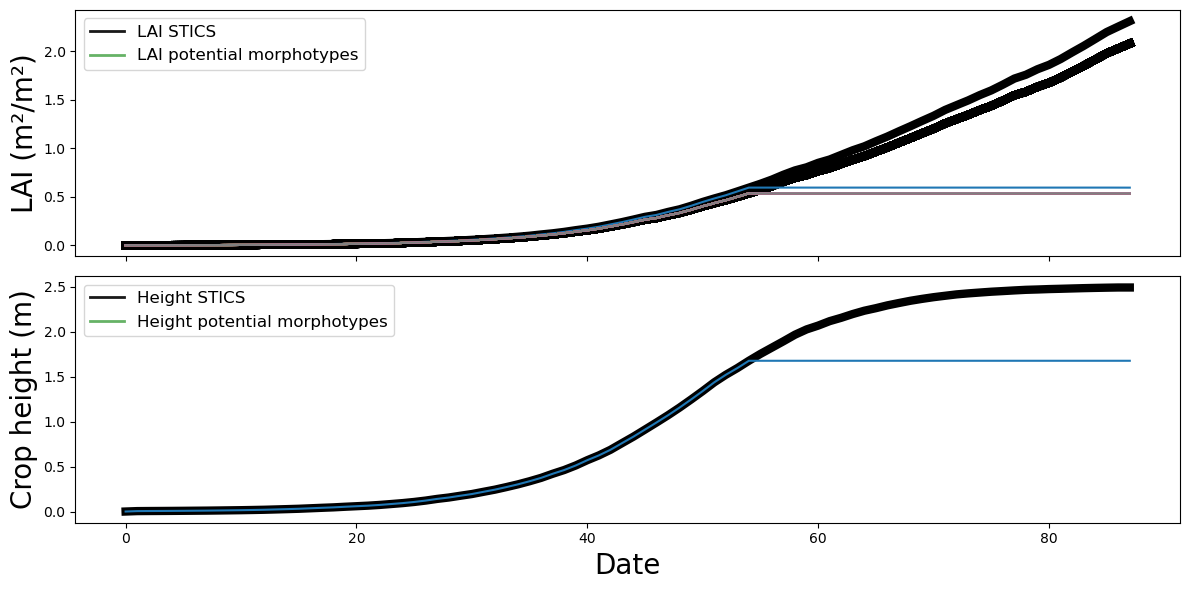

[0.000000e+00 3.200000e-02 5.760000e-01 1.264000e+00 2.208000e+00
 3.408000e+00 4.720000e+00 6.704000e+00 9.200000e+00 1.203200e+01
 1.608000e+01 2.124800e+01 2.920000e+01 3.851200e+01 4.945600e+01
 6.600000e+01 8.462400e+01 1.033920e+02 1.308320e+02 1.581120e+02
 1.879360e+02 2.300160e+02 2.851040e+02 3.466080e+02 4.255040e+02
 5.259360e+02 6.526400e+02 7.611360e+02 9.024960e+02 1.025488e+03
 1.178144e+03 1.324752e+03 1.492512e+03 1.664528e+03 1.849872e+03
 2.043536e+03 2.265888e+03 2.460688e+03 2.683088e+03 2.923520e+03
 3.130592e+03 3.358624e+03 3.641152e+03 3.878704e+03 4.159472e+03
 4.397872e+03 4.636848e+03 4.869632e+03 5.115472e+03 5.366352e+03
 5.609584e+03 5.791536e+03 5.939872e+03 6.084064e+03 6.181056e+03
 6.054368e+03 5.945856e+03 5.804512e+03 5.680416e+03 5.526384e+03
 5.377888e+03 5.207744e+03 5.033088e+03 4.843776e+03 4.645120e+03
 4.417120e+03 4.417120e+03 4.214224e+03 3.981488e+03 3.981488e+03
 3.725152e+03 3.499440e+03 3.249520e+03 3.249520e+03 2.966992e+03
 2.696352e

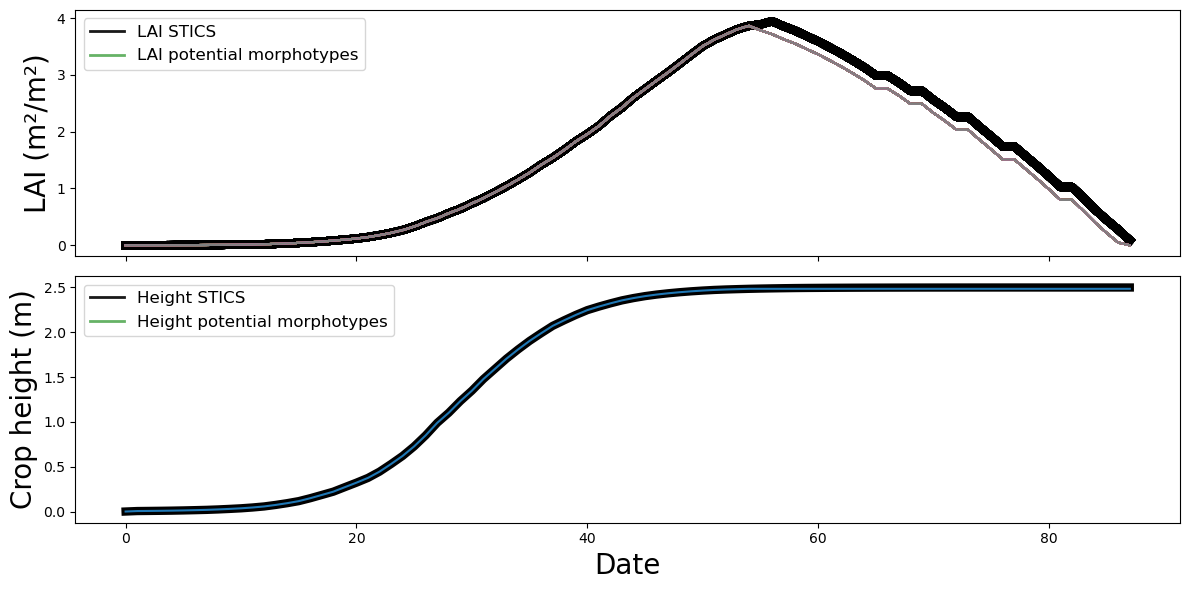

[0.000000e+00 3.560000e-02 6.578000e-01 1.368900e+00 2.222200e+00
 3.182200e+00 4.106600e+00 5.368800e+00 6.791000e+00 8.213200e+00
 1.006210e+01 1.217770e+01 1.512880e+01 1.818660e+01 2.136880e+01
 2.579550e+01 3.023990e+01 3.420430e+01 3.966210e+01 4.449770e+01
 4.933330e+01 5.591110e+01 6.408890e+01 7.256890e+01 8.304000e+01
 9.592890e+01 1.117689e+02 1.243022e+02 1.408711e+02 1.565689e+02
 1.778311e+02 1.984889e+02 2.234845e+02 2.429156e+02 2.651378e+02
 2.897245e+02 3.203201e+02 3.481423e+02 3.829156e+02 4.245512e+02
 4.622045e+02 5.074845e+02 5.636623e+02 6.204979e+02 6.837690e+02
 7.493868e+02 7.612979e+02 7.850668e+02 7.988268e+02 8.247646e+02
 8.479113e+02 8.642846e+02 8.827202e+02 9.033246e+02 9.173335e+02
 9.173335e+02 9.173335e+02 9.173335e+02 9.173335e+02 9.173335e+02
 9.173335e+02 9.173335e+02 9.173335e+02 9.173335e+02 9.173335e+02
 9.173335e+02 9.173335e+02 9.173335e+02 9.173335e+02 9.173335e+02
 9.173335e+02 9.173335e+02 9.173335e+02 9.173335e+02 9.173335e+02
 9.173335e

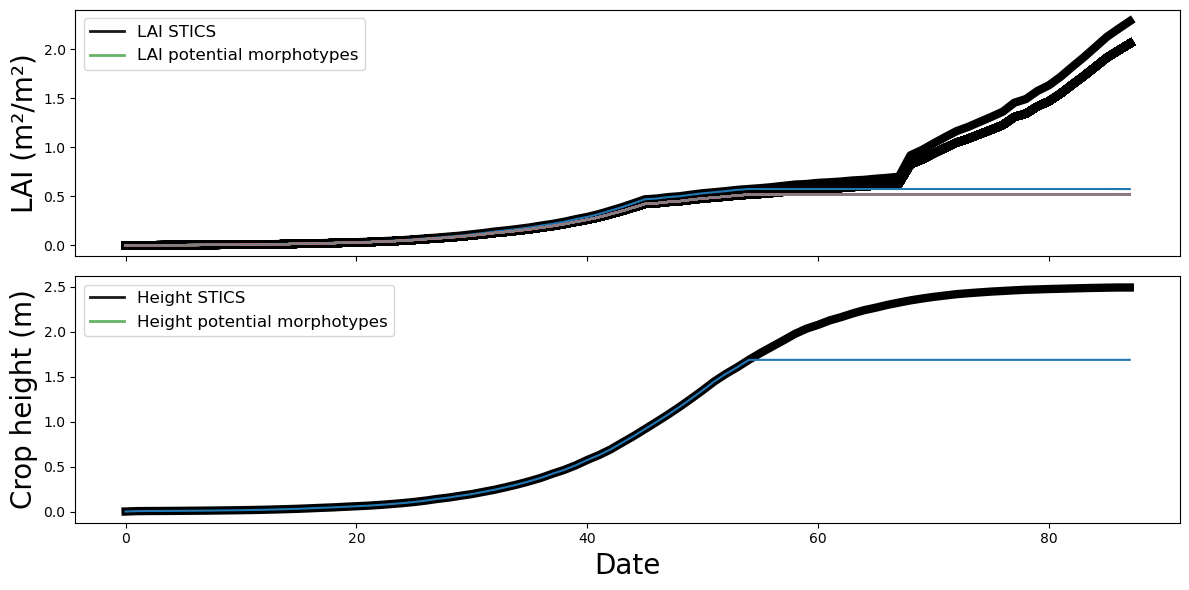

[0.000000e+00 3.200000e-02 5.760000e-01 1.264000e+00 2.208000e+00
 3.408000e+00 4.720000e+00 6.704000e+00 9.200000e+00 1.201600e+01
 1.606400e+01 2.123200e+01 2.921600e+01 3.854400e+01 4.950400e+01
 6.609600e+01 8.472000e+01 1.035040e+02 1.310880e+02 1.584160e+02
 1.882880e+02 2.306560e+02 2.858720e+02 3.475040e+02 4.269760e+02
 5.268000e+02 6.542560e+02 7.630080e+02 9.050400e+02 1.028272e+03
 1.181120e+03 1.327968e+03 1.496016e+03 1.668096e+03 1.853648e+03
 2.047488e+03 2.269984e+03 2.464880e+03 2.687360e+03 2.927744e+03
 3.134784e+03 3.362736e+03 3.645072e+03 3.882336e+03 4.125648e+03
 4.401008e+03 4.639568e+03 4.871584e+03 5.117024e+03 5.367232e+03
 5.609120e+03 5.790224e+03 5.938000e+03 6.080208e+03 6.177696e+03
 6.050240e+03 5.941504e+03 5.799456e+03 5.675136e+03 5.520912e+03
 5.372160e+03 5.201744e+03 5.027024e+03 4.837504e+03 4.638688e+03
 4.410528e+03 4.410528e+03 4.410528e+03 4.207536e+03 3.974736e+03
 3.718384e+03 3.492688e+03 3.242816e+03 2.960480e+03 2.960480e+03
 2.690032e

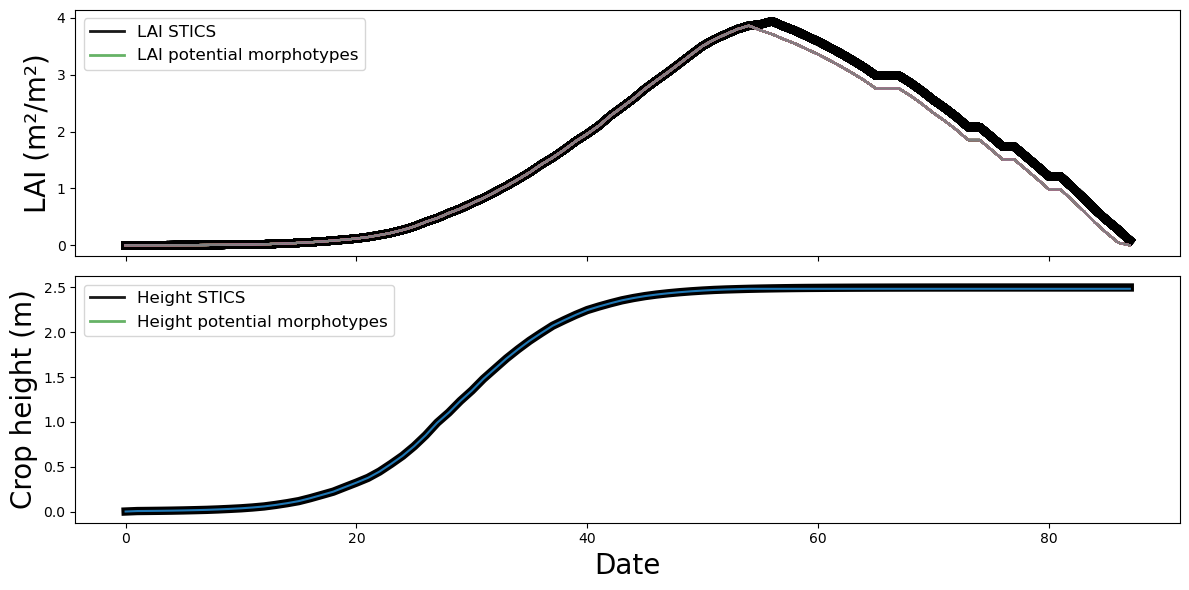

[0.0000000e+00 3.5600000e-02 6.5780000e-01 1.3689000e+00 2.2222000e+00
 3.1822000e+00 4.1066000e+00 5.3688000e+00 6.7910000e+00 8.2132000e+00
 1.0062100e+01 1.2177700e+01 1.5146600e+01 1.8186600e+01 2.1386600e+01
 2.5831000e+01 3.0275400e+01 3.4222100e+01 3.9715400e+01 4.4551000e+01
 4.9404300e+01 5.6035400e+01 6.4231000e+01 7.2728800e+01 8.3271000e+01
 9.6053200e+01 1.1201760e+02 1.2456870e+02 1.4124430e+02 1.5697760e+02
 1.7831090e+02 1.9905760e+02 2.2417760e+02 2.4366200e+02 2.6597310e+02
 2.9064870e+02 3.2135090e+02 3.4924420e+02 3.8412420e+02 4.2586640e+02
 4.6359080e+02 5.0895970e+02 5.6522640e+02 6.2211530e+02 6.8542200e+02
 7.5105760e+02 7.8559980e+02 8.5822200e+02 9.0391090e+02 9.8871090e+02
 1.0748442e+03 1.1389331e+03 1.2145953e+03 1.3038220e+03 1.3665420e+03
 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03
 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03
 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03
 1.366

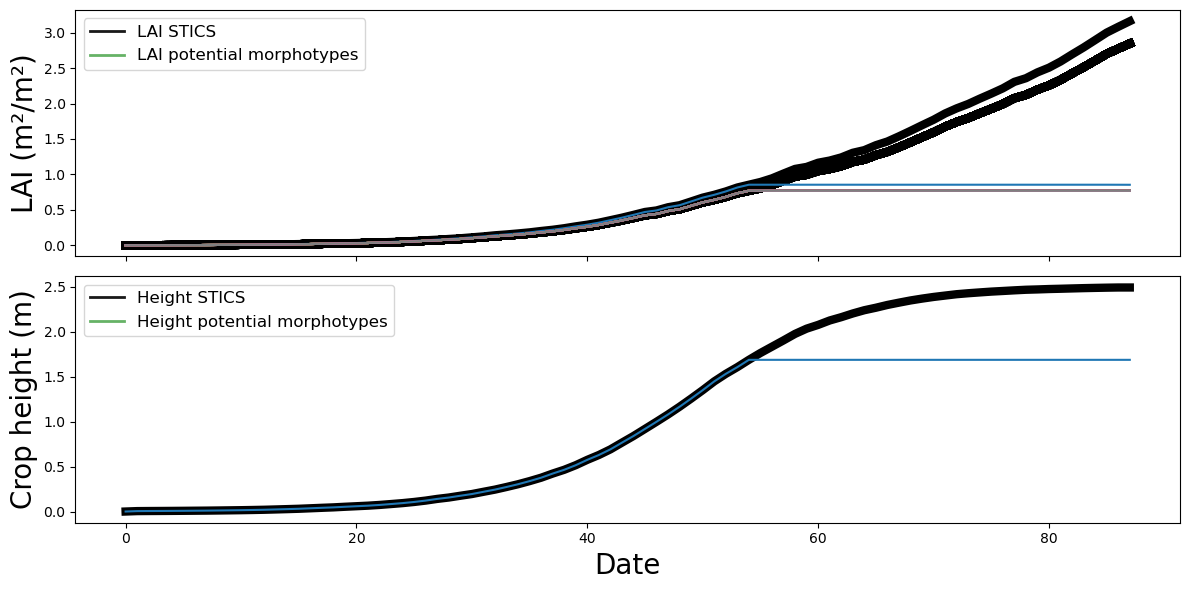

[0.000000e+00 2.400000e-02 5.760000e-01 1.264000e+00 2.216000e+00
 3.408000e+00 4.720000e+00 6.704000e+00 9.200000e+00 1.203200e+01
 1.608000e+01 2.124800e+01 2.911200e+01 3.838400e+01 4.918400e+01
 6.524800e+01 8.367200e+01 1.022560e+02 1.289360e+02 1.558800e+02
 1.853520e+02 2.272160e+02 2.818320e+02 3.427280e+02 4.218720e+02
 5.035040e+02 6.081840e+02 6.977440e+02 8.148560e+02 9.276800e+02
 1.069248e+03 1.205112e+03 1.360960e+03 1.520920e+03 1.693232e+03
 1.872768e+03 2.079144e+03 2.259336e+03 2.465264e+03 2.687440e+03
 2.878312e+03 3.088344e+03 3.350680e+03 3.569296e+03 3.829360e+03
 4.047472e+03 4.266344e+03 4.479200e+03 4.702488e+03 4.930496e+03
 5.149176e+03 5.309696e+03 5.438368e+03 5.558680e+03 5.670240e+03
 5.565560e+03 5.476000e+03 5.358888e+03 5.244960e+03 5.102016e+03
 4.964256e+03 4.806016e+03 4.643432e+03 4.467160e+03 4.282624e+03
 4.070584e+03 3.882296e+03 3.666032e+03 3.428128e+03 3.428128e+03
 3.428128e+03 3.218712e+03 2.987080e+03 2.987080e+03 2.724736e+03
 2.473992e

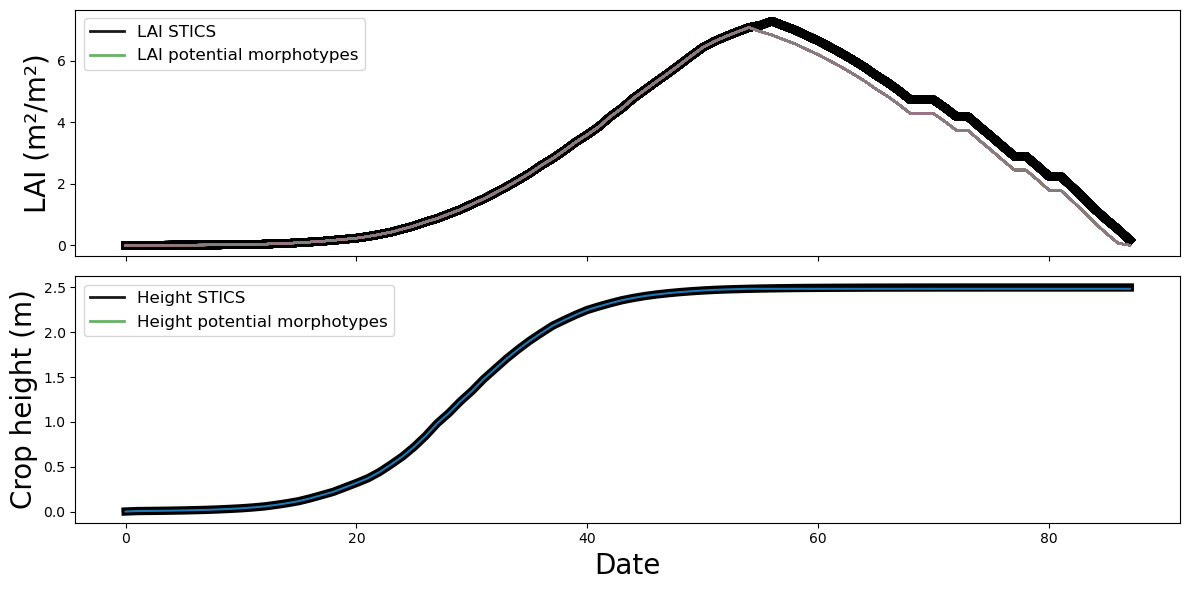

[0.000000e+00 4.440000e-02 6.666000e-01 1.368800e+00 2.222100e+00
 3.182100e+00 4.106500e+00 5.377600e+00 6.799800e+00 8.222000e+00
 1.007090e+01 1.218650e+01 1.510210e+01 1.813320e+01 2.128880e+01
 2.558210e+01 2.998210e+01 3.391100e+01 3.922660e+01 4.401770e+01
 4.880880e+01 5.538660e+01 6.351100e+01 7.191990e+01 8.244430e+01
 9.514650e+01 1.110576e+02 1.236087e+02 1.322220e+02 1.403109e+02
 1.513687e+02 1.621243e+02 1.751821e+02 1.890932e+02 2.050399e+02
 2.226221e+02 2.445688e+02 2.644799e+02 2.894310e+02 3.192710e+02
 3.462666e+02 3.787022e+02 4.190578e+02 4.597867e+02 5.051111e+02
 5.520533e+02 5.540444e+02 5.574311e+02 5.587378e+02 5.620711e+02
 5.645955e+02 5.658133e+02 5.672444e+02 5.690044e+02 5.697155e+02
 5.697155e+02 5.697155e+02 5.697155e+02 5.697155e+02 5.697155e+02
 5.697155e+02 5.697155e+02 5.697155e+02 5.697155e+02 5.697155e+02
 5.697155e+02 5.697155e+02 5.697155e+02 5.697155e+02 5.697155e+02
 5.697155e+02 5.697155e+02 5.697155e+02 5.697155e+02 5.697155e+02
 5.697155e

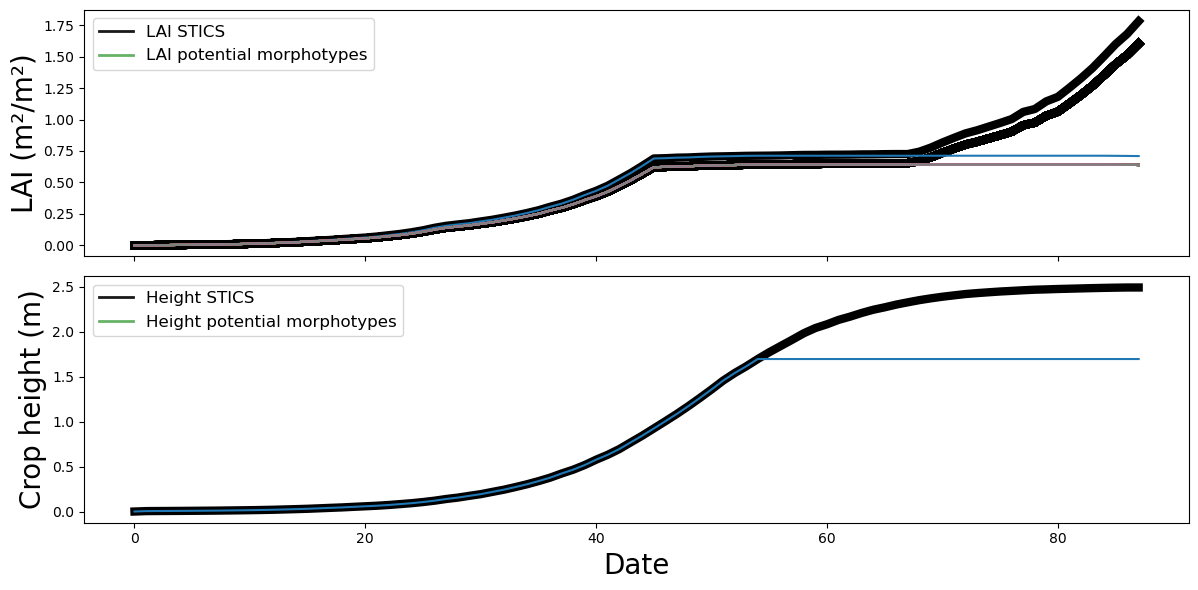

[0.000000e+00 2.400000e-02 5.760000e-01 1.264000e+00 2.216000e+00
 3.408000e+00 4.720000e+00 6.704000e+00 9.200000e+00 1.202400e+01
 1.607200e+01 2.124800e+01 2.918400e+01 3.849600e+01 4.942400e+01
 6.589600e+01 8.456000e+01 1.033120e+02 1.305920e+02 1.578240e+02
 1.876000e+02 2.301440e+02 2.856160e+02 3.471920e+02 4.274880e+02
 5.102160e+02 6.161840e+02 7.067600e+02 8.250240e+02 9.388480e+02
 1.080384e+03 1.216184e+03 1.371856e+03 1.531520e+03 1.703464e+03
 1.882560e+03 2.088344e+03 2.268056e+03 2.473288e+03 2.694832e+03
 2.884992e+03 3.094232e+03 3.322592e+03 3.572664e+03 3.794440e+03
 4.048672e+03 4.266056e+03 4.476504e+03 4.670552e+03 4.896784e+03
 5.112792e+03 5.270496e+03 5.397072e+03 5.513880e+03 5.622152e+03
 5.678448e+03 5.587872e+03 5.469608e+03 5.354680e+03 5.211768e+03
 5.074072e+03 4.916016e+03 4.753720e+03 4.577816e+03 4.393728e+03
 4.182280e+03 3.994480e+03 3.994480e+03 3.778896e+03 3.541480e+03
 3.541480e+03 3.541480e+03 3.332696e+03 3.101600e+03 2.840296e+03
 2.590224e

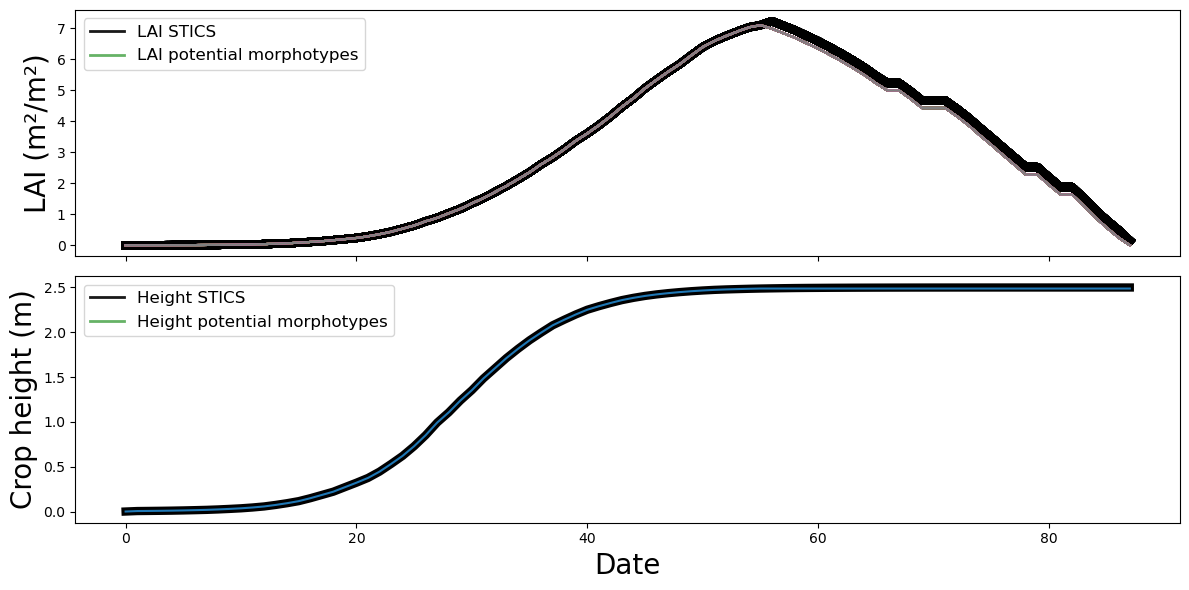

[0.000000e+00 4.440000e-02 6.666000e-01 1.368800e+00 2.222100e+00
 3.182100e+00 4.106500e+00 5.377600e+00 6.799800e+00 8.222000e+00
 1.007090e+01 1.218650e+01 1.512870e+01 1.817760e+01 2.135980e+01
 2.577760e+01 3.022200e+01 3.417760e+01 3.959980e+01 4.443540e+01
 4.926210e+01 5.593770e+01 6.417770e+01 7.266660e+01 8.334220e+01
 9.620440e+01 1.123200e+02 1.250222e+02 1.337333e+02 1.419111e+02
 1.530755e+02 1.639288e+02 1.771021e+02 1.911199e+02 2.071643e+02
 2.248532e+02 2.469065e+02 2.669154e+02 2.919554e+02 3.219287e+02
 3.490043e+02 3.815465e+02 4.219198e+02 4.627198e+02 5.080354e+02
 5.549954e+02 5.708176e+02 6.040532e+02 6.235288e+02 6.616888e+02
 6.966932e+02 7.217954e+02 7.507998e+02 7.843198e+02 8.071465e+02
 8.071465e+02 8.071465e+02 8.071465e+02 8.071465e+02 8.071465e+02
 8.071465e+02 8.071465e+02 8.071465e+02 8.071465e+02 8.071465e+02
 8.071465e+02 8.071465e+02 8.071465e+02 8.071465e+02 8.071465e+02
 8.071465e+02 8.071465e+02 8.071465e+02 8.071465e+02 8.071465e+02
 8.071465e

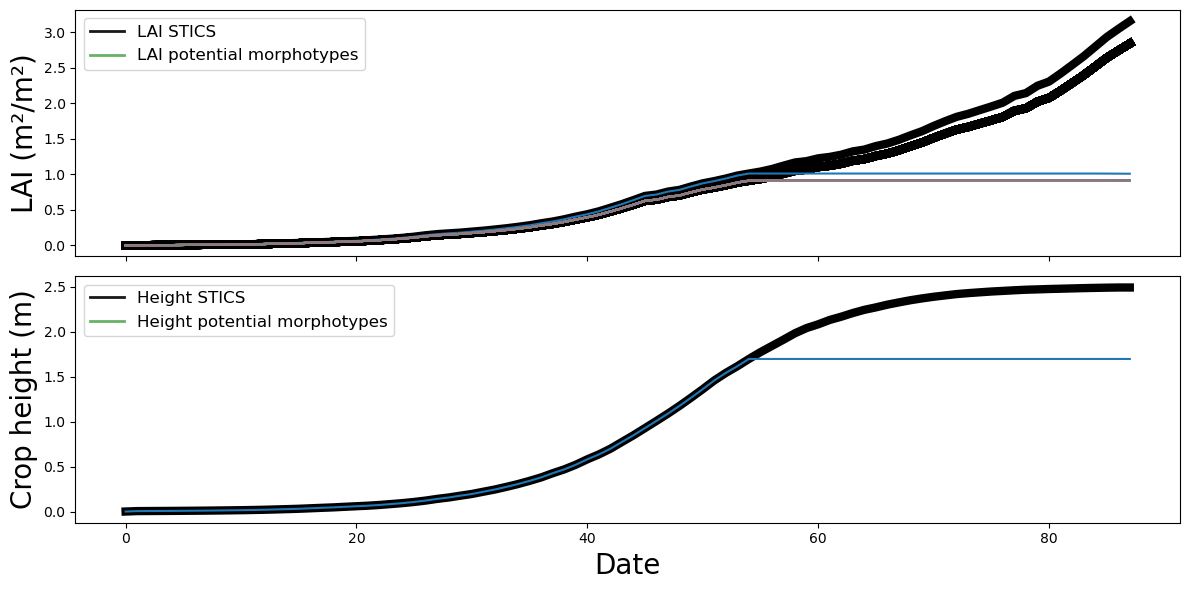

[0.000000e+00 3.200000e-02 5.760000e-01 1.264000e+00 2.208000e+00
 3.408000e+00 4.720000e+00 6.704000e+00 9.200000e+00 1.203200e+01
 1.608000e+01 2.124800e+01 2.920000e+01 3.851200e+01 4.945600e+01
 6.600000e+01 8.462400e+01 1.033920e+02 1.308320e+02 1.581120e+02
 1.879360e+02 2.299360e+02 2.850080e+02 3.464960e+02 4.250400e+02
 5.261600e+02 6.520000e+02 7.604480e+02 9.011200e+02 1.024000e+03
 1.175504e+03 1.321328e+03 1.488000e+03 1.658608e+03 1.842816e+03
 2.035392e+03 2.256496e+03 2.450528e+03 2.671776e+03 2.910944e+03
 3.117280e+03 3.344256e+03 3.625664e+03 3.895232e+03 4.142160e+03
 4.379552e+03 4.617280e+03 4.848880e+03 5.094160e+03 5.343584e+03
 5.585552e+03 5.766672e+03 5.914368e+03 6.057984e+03 6.152896e+03
 6.192352e+03 6.083920e+03 5.943248e+03 5.819264e+03 5.666384e+03
 5.518672e+03 5.349616e+03 5.176368e+03 4.988192e+03 4.790624e+03
 4.790624e+03 4.563856e+03 4.563856e+03 4.361744e+03 4.130144e+03
 3.875072e+03 3.650096e+03 3.401248e+03 3.119840e+03 3.119840e+03
 2.850272e

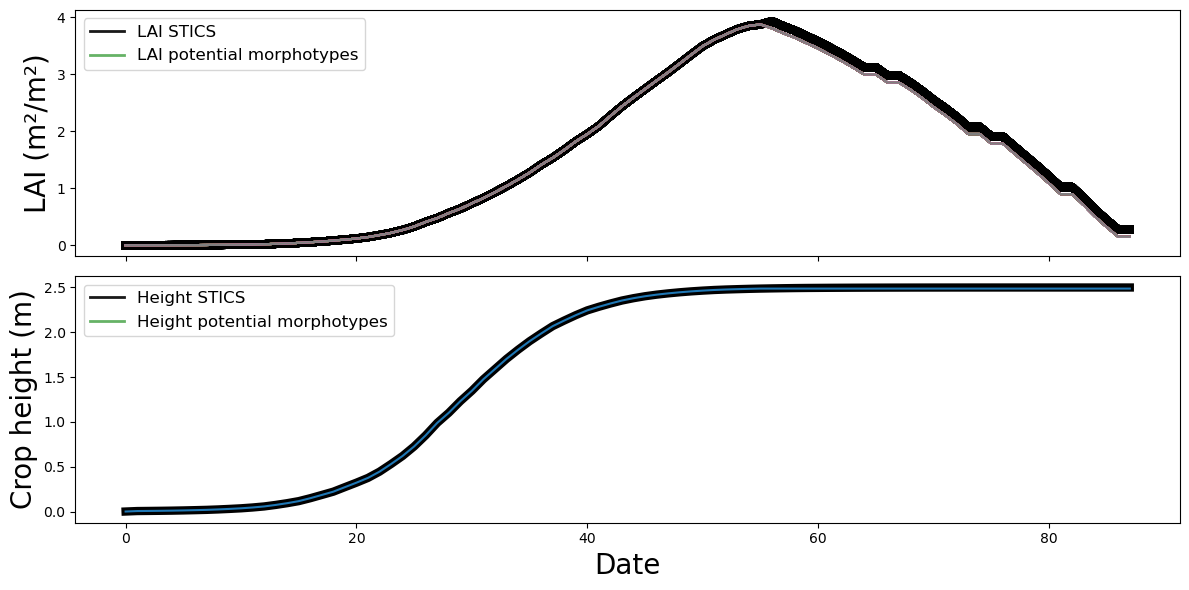

[0.000000e+00 3.560000e-02 6.578000e-01 1.368900e+00 2.222200e+00
 3.182200e+00 4.106600e+00 5.368800e+00 6.791000e+00 8.213200e+00
 1.006210e+01 1.217770e+01 1.512880e+01 1.818660e+01 2.136880e+01
 2.579550e+01 3.023990e+01 3.420430e+01 3.966210e+01 4.449770e+01
 4.933330e+01 5.591110e+01 6.407110e+01 7.255110e+01 8.296890e+01
 9.594670e+01 1.116800e+02 1.241956e+02 1.406756e+02 1.563556e+02
 1.773689e+02 1.978489e+02 2.225956e+02 2.417778e+02 2.637689e+02
 2.880889e+02 3.183645e+02 3.459378e+02 3.803378e+02 4.215289e+02
 4.588622e+02 5.036800e+02 5.593067e+02 6.155734e+02 6.783112e+02
 7.433245e+02 7.530312e+02 7.732623e+02 7.838756e+02 8.109156e+02
 8.359645e+02 8.526756e+02 8.739200e+02 9.009600e+02 9.174756e+02
 9.174756e+02 9.174756e+02 9.174756e+02 9.174756e+02 9.174756e+02
 9.174756e+02 9.174756e+02 9.174756e+02 9.174756e+02 9.174756e+02
 9.174756e+02 9.174756e+02 9.174756e+02 9.174756e+02 9.174756e+02
 9.174756e+02 9.174756e+02 9.174756e+02 9.174756e+02 9.174756e+02
 9.174756e

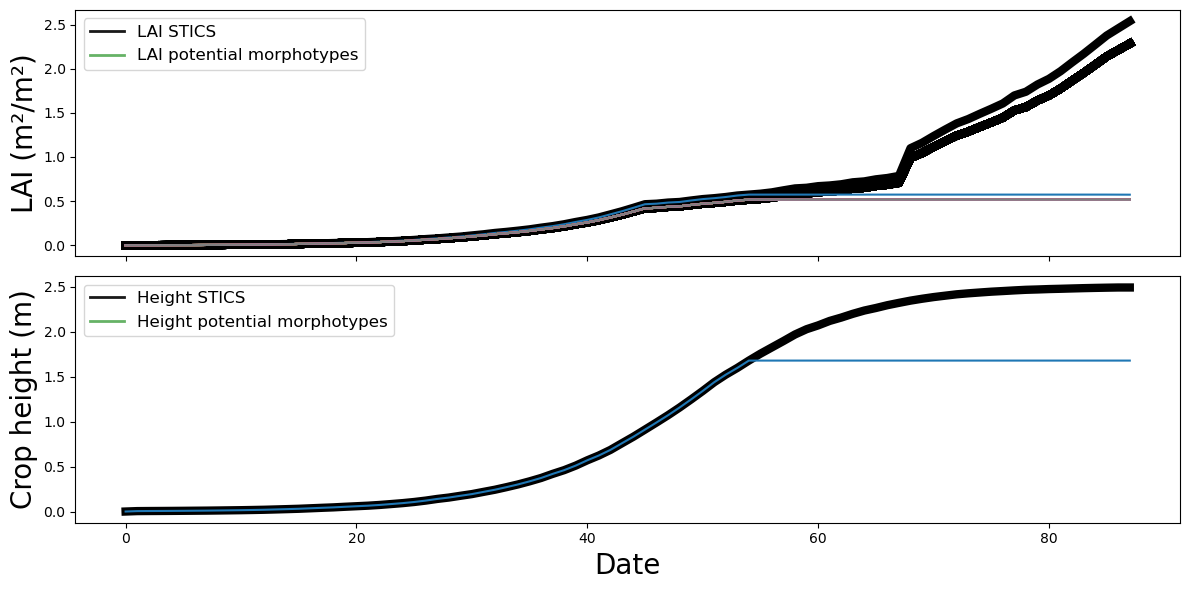

[0.000000e+00 3.200000e-02 5.760000e-01 1.264000e+00 2.208000e+00
 3.408000e+00 4.720000e+00 6.704000e+00 9.200000e+00 1.201600e+01
 1.606400e+01 2.123200e+01 2.921600e+01 3.854400e+01 4.950400e+01
 6.609600e+01 8.472000e+01 1.035040e+02 1.310880e+02 1.584160e+02
 1.882880e+02 2.306560e+02 2.858720e+02 3.475040e+02 4.269760e+02
 5.268000e+02 6.542560e+02 7.630080e+02 9.050400e+02 1.028272e+03
 1.181120e+03 1.327968e+03 1.496016e+03 1.668096e+03 1.853648e+03
 2.047488e+03 2.269984e+03 2.464880e+03 2.687360e+03 2.927744e+03
 3.134784e+03 3.362736e+03 3.645072e+03 3.882336e+03 4.125648e+03
 4.401008e+03 4.639568e+03 4.871584e+03 5.117024e+03 5.367232e+03
 5.609120e+03 5.790224e+03 5.938000e+03 6.080208e+03 6.177696e+03
 6.050240e+03 5.941504e+03 5.799456e+03 5.675136e+03 5.520912e+03
 5.372160e+03 5.201744e+03 5.027024e+03 4.837504e+03 4.638688e+03
 4.410528e+03 4.410528e+03 4.410528e+03 4.207536e+03 3.974736e+03
 3.718384e+03 3.492688e+03 3.242816e+03 2.960480e+03 2.960480e+03
 2.690032e

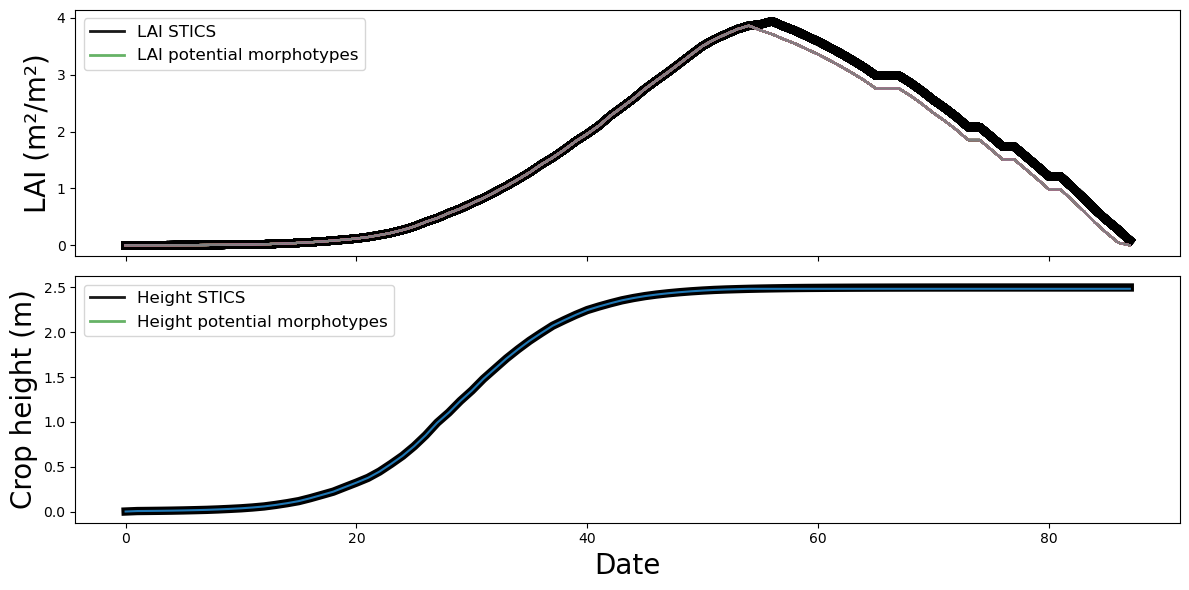

[0.0000000e+00 3.5600000e-02 6.5780000e-01 1.3689000e+00 2.2222000e+00
 3.1822000e+00 4.1066000e+00 5.3688000e+00 6.7910000e+00 8.2132000e+00
 1.0062100e+01 1.2177700e+01 1.5146600e+01 1.8186600e+01 2.1386600e+01
 2.5831000e+01 3.0275400e+01 3.4222100e+01 3.9715400e+01 4.4551000e+01
 4.9404300e+01 5.6035400e+01 6.4231000e+01 7.2728800e+01 8.3271000e+01
 9.6053200e+01 1.1201760e+02 1.2456870e+02 1.4124430e+02 1.5697760e+02
 1.7831090e+02 1.9905760e+02 2.2417760e+02 2.4366200e+02 2.6597310e+02
 2.9064870e+02 3.2135090e+02 3.4924420e+02 3.8412420e+02 4.2586640e+02
 4.6359080e+02 5.0895970e+02 5.6522640e+02 6.2211530e+02 6.8542200e+02
 7.5105760e+02 7.8559980e+02 8.5822200e+02 9.0391090e+02 9.8871090e+02
 1.0748442e+03 1.1389331e+03 1.2145953e+03 1.3038220e+03 1.3665420e+03
 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03
 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03
 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03
 1.366

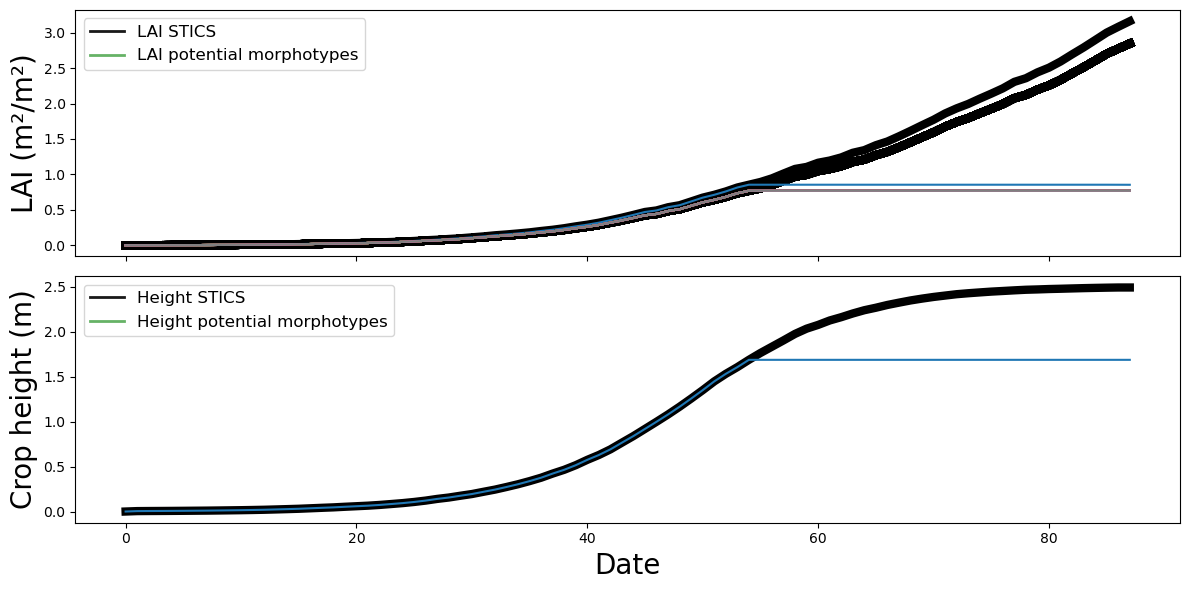

[0.000000e+00 3.200000e-02 5.760000e-01 1.264000e+00 2.208000e+00
 3.408000e+00 4.720000e+00 6.704000e+00 9.200000e+00 1.203200e+01
 1.608000e+01 2.124800e+01 2.920000e+01 3.851200e+01 4.945600e+01
 6.600000e+01 8.462400e+01 1.033920e+02 1.308320e+02 1.581120e+02
 1.879360e+02 2.299040e+02 2.849760e+02 3.464640e+02 4.250080e+02
 5.261600e+02 6.520000e+02 7.604480e+02 9.011200e+02 1.024000e+03
 1.175456e+03 1.321296e+03 1.487840e+03 1.658352e+03 1.842384e+03
 2.034768e+03 2.255632e+03 2.449456e+03 2.670448e+03 2.909296e+03
 3.115296e+03 3.341872e+03 3.622880e+03 3.892000e+03 4.138448e+03
 4.375376e+03 4.612672e+03 4.844048e+03 5.088864e+03 5.337856e+03
 5.579360e+03 5.759920e+03 5.907056e+03 6.050144e+03 6.144352e+03
 6.018512e+03 5.910080e+03 5.769408e+03 5.645424e+03 5.492592e+03
 5.344864e+03 5.175920e+03 5.002784e+03 4.814784e+03 4.617408e+03
 4.617408e+03 4.617408e+03 4.390896e+03 4.188960e+03 3.957632e+03
 3.702896e+03 3.478256e+03 3.229776e+03 2.948784e+03 2.948784e+03
 2.679664e

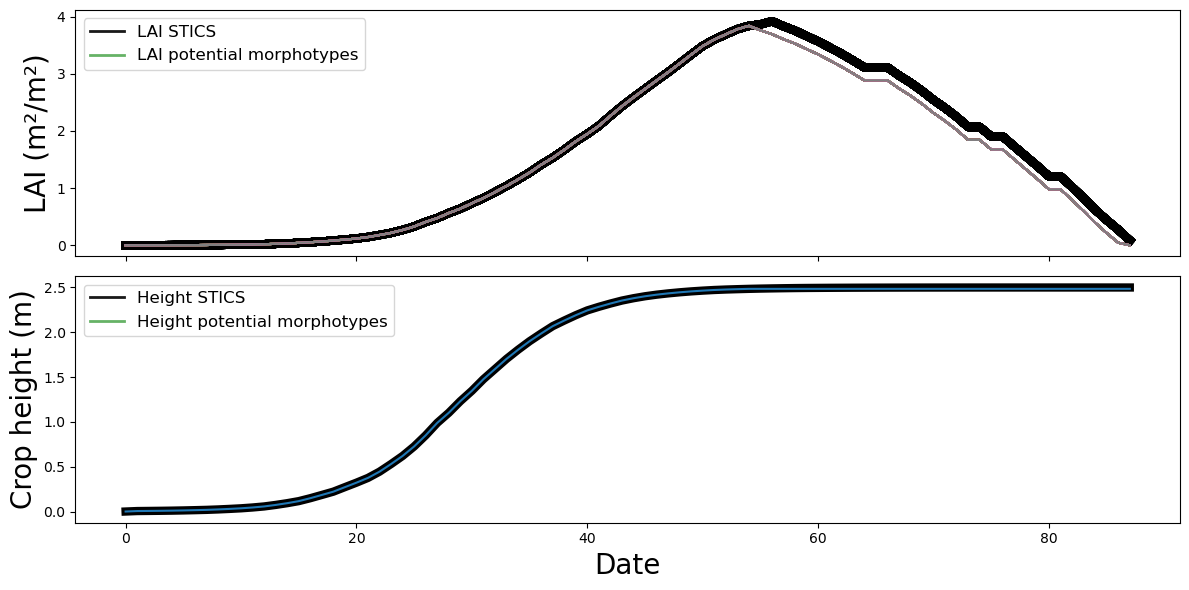

[0.000000e+00 3.560000e-02 6.578000e-01 1.368900e+00 2.222200e+00
 3.182200e+00 4.106600e+00 5.368800e+00 6.791000e+00 8.213200e+00
 1.006210e+01 1.217770e+01 1.512880e+01 1.818660e+01 2.136880e+01
 2.579550e+01 3.023990e+01 3.420430e+01 3.966210e+01 4.449770e+01
 4.933330e+01 5.589330e+01 6.407110e+01 7.255110e+01 8.296890e+01
 9.594670e+01 1.116800e+02 1.241956e+02 1.406756e+02 1.563556e+02
 1.773689e+02 1.978489e+02 2.225778e+02 2.417245e+02 2.636978e+02
 2.879822e+02 3.182044e+02 3.457244e+02 3.800888e+02 4.211910e+02
 4.584177e+02 5.031288e+02 5.586132e+02 6.147199e+02 6.772621e+02
 7.420799e+02 7.547555e+02 7.817422e+02 7.973866e+02 8.332266e+02
 8.676088e+02 8.925510e+02 9.237332e+02 9.623643e+02 9.884087e+02
 9.884087e+02 9.884087e+02 9.884087e+02 9.884087e+02 9.884087e+02
 9.884087e+02 9.884087e+02 9.884087e+02 9.884087e+02 9.884087e+02
 9.884087e+02 9.884087e+02 9.884087e+02 9.884087e+02 9.884087e+02
 9.884087e+02 9.884087e+02 9.884087e+02 9.884087e+02 9.884087e+02
 9.884087e

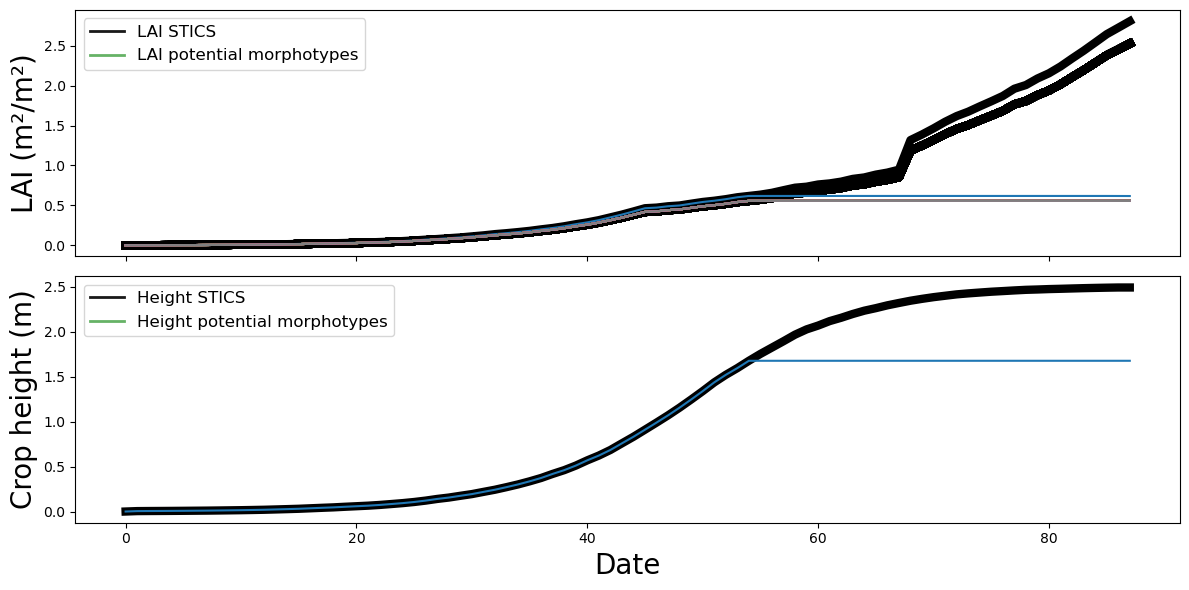

[0.000000e+00 3.200000e-02 5.760000e-01 1.264000e+00 2.208000e+00
 3.408000e+00 4.720000e+00 6.704000e+00 9.200000e+00 1.201600e+01
 1.606400e+01 2.123200e+01 2.921600e+01 3.854400e+01 4.950400e+01
 6.609600e+01 8.472000e+01 1.035040e+02 1.310880e+02 1.584160e+02
 1.882880e+02 2.306560e+02 2.858720e+02 3.475040e+02 4.269760e+02
 5.268000e+02 6.542560e+02 7.630080e+02 9.050400e+02 1.028272e+03
 1.181120e+03 1.327968e+03 1.496016e+03 1.668096e+03 1.853648e+03
 2.047488e+03 2.269984e+03 2.464880e+03 2.687360e+03 2.927744e+03
 3.134784e+03 3.362736e+03 3.645072e+03 3.882336e+03 4.125648e+03
 4.401008e+03 4.639568e+03 4.871584e+03 5.117024e+03 5.367232e+03
 5.609120e+03 5.790224e+03 5.938000e+03 6.080208e+03 6.177696e+03
 6.050240e+03 5.941504e+03 5.799456e+03 5.675136e+03 5.520912e+03
 5.372160e+03 5.201744e+03 5.027024e+03 4.837504e+03 4.638688e+03
 4.410528e+03 4.410528e+03 4.410528e+03 4.207536e+03 3.974736e+03
 3.718384e+03 3.492688e+03 3.242816e+03 2.960480e+03 2.960480e+03
 2.690032e

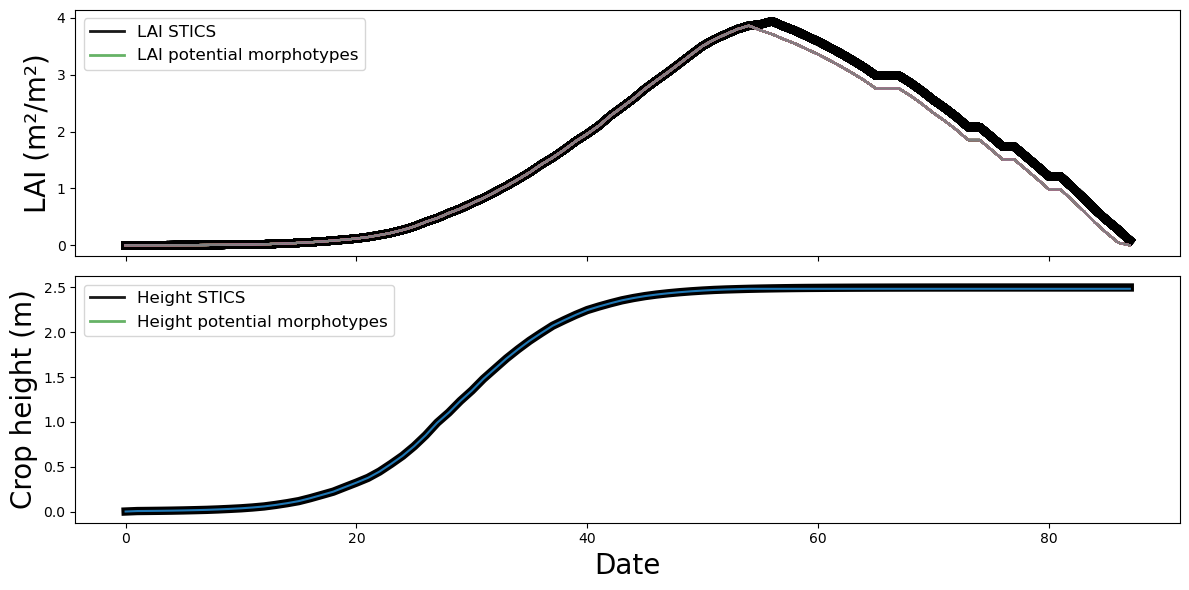

[0.0000000e+00 3.5600000e-02 6.5780000e-01 1.3689000e+00 2.2222000e+00
 3.1822000e+00 4.1066000e+00 5.3688000e+00 6.7910000e+00 8.2132000e+00
 1.0062100e+01 1.2177700e+01 1.5146600e+01 1.8186600e+01 2.1386600e+01
 2.5831000e+01 3.0275400e+01 3.4222100e+01 3.9715400e+01 4.4551000e+01
 4.9404300e+01 5.6035400e+01 6.4231000e+01 7.2728800e+01 8.3271000e+01
 9.6053200e+01 1.1201760e+02 1.2456870e+02 1.4124430e+02 1.5697760e+02
 1.7831090e+02 1.9905760e+02 2.2417760e+02 2.4366200e+02 2.6597310e+02
 2.9064870e+02 3.2135090e+02 3.4924420e+02 3.8412420e+02 4.2586640e+02
 4.6359080e+02 5.0895970e+02 5.6522640e+02 6.2211530e+02 6.8542200e+02
 7.5105760e+02 7.8559980e+02 8.5822200e+02 9.0391090e+02 9.8871090e+02
 1.0748442e+03 1.1389331e+03 1.2145953e+03 1.3038220e+03 1.3665420e+03
 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03
 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03
 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03
 1.366

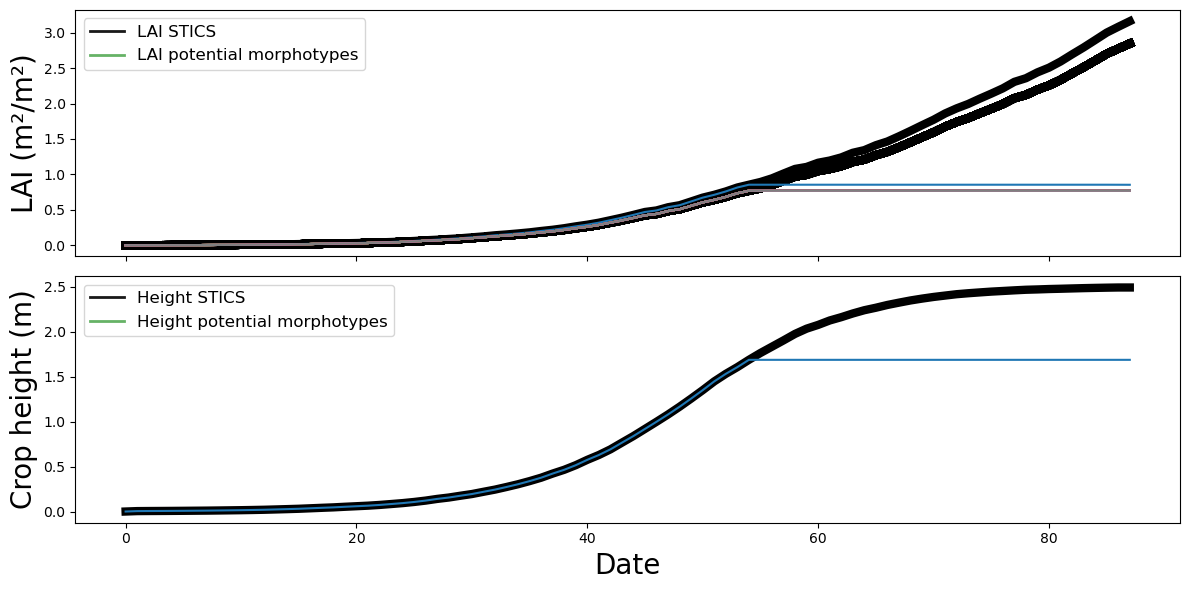

[0.000000e+00 3.200000e-02 5.760000e-01 1.264000e+00 2.208000e+00
 3.408000e+00 4.720000e+00 6.704000e+00 9.200000e+00 1.203200e+01
 1.608000e+01 2.124800e+01 2.920000e+01 3.851200e+01 4.945600e+01
 6.600000e+01 8.462400e+01 1.033920e+02 1.308320e+02 1.581120e+02
 1.879360e+02 2.299040e+02 2.849760e+02 3.464640e+02 4.250080e+02
 5.261920e+02 6.520160e+02 7.604640e+02 9.011360e+02 1.024016e+03
 1.175408e+03 1.314864e+03 1.481232e+03 1.651568e+03 1.835344e+03
 2.027408e+03 2.247872e+03 2.441664e+03 2.662240e+03 2.900576e+03
 3.106064e+03 3.332064e+03 3.612400e+03 3.880832e+03 4.126528e+03
 4.362736e+03 4.599568e+03 4.830144e+03 5.074208e+03 5.322480e+03
 5.563376e+03 5.743008e+03 5.889232e+03 6.031664e+03 6.124832e+03
 5.998992e+03 5.890560e+03 5.749888e+03 5.625904e+03 5.473136e+03
 5.331792e+03 5.163024e+03 4.990064e+03 4.802336e+03 4.802336e+03
 4.802336e+03 4.605264e+03 4.379136e+03 4.177264e+03 3.946336e+03
 3.692096e+03 3.467984e+03 3.220096e+03 2.939744e+03 2.939744e+03
 2.671328e

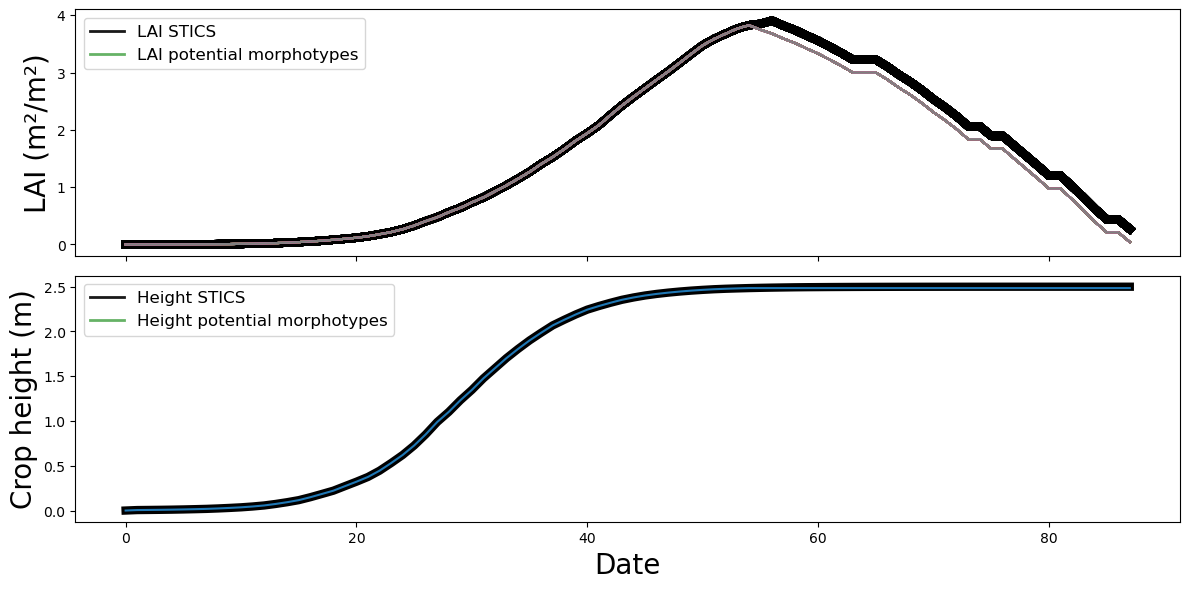

[0.0000000e+00 3.5600000e-02 6.5780000e-01 1.3689000e+00 2.2222000e+00
 3.1822000e+00 4.1066000e+00 5.3688000e+00 6.7910000e+00 8.2132000e+00
 1.0062100e+01 1.2177700e+01 1.5128800e+01 1.8186600e+01 2.1368800e+01
 2.5795500e+01 3.0239900e+01 3.4204300e+01 3.9662100e+01 4.4497700e+01
 4.9333300e+01 5.5893300e+01 6.4071100e+01 7.2551100e+01 8.2968900e+01
 9.5946700e+01 1.1168000e+02 1.2419560e+02 1.4067560e+02 1.5635560e+02
 1.7735120e+02 1.9783120e+02 2.2252450e+02 2.4165340e+02 2.6357340e+02
 2.8780450e+02 3.1797340e+02 3.4547560e+02 3.7973340e+02 4.2071120e+02
 4.5779560e+02 5.0232890e+02 5.5760000e+02 6.1345780e+02 6.7571560e+02
 7.4021340e+02 7.5776010e+02 7.9665790e+02 8.2183120e+02 8.7306680e+02
 9.2405350e+02 9.6424910e+02 1.0135824e+03 1.0730313e+03 1.1174402e+03
 1.1174402e+03 1.1174402e+03 1.1174402e+03 1.1174402e+03 1.1174402e+03
 1.1174402e+03 1.1174402e+03 1.1174402e+03 1.1174402e+03 1.1174402e+03
 1.1174402e+03 1.1174402e+03 1.1174402e+03 1.1174402e+03 1.1174402e+03
 1.117

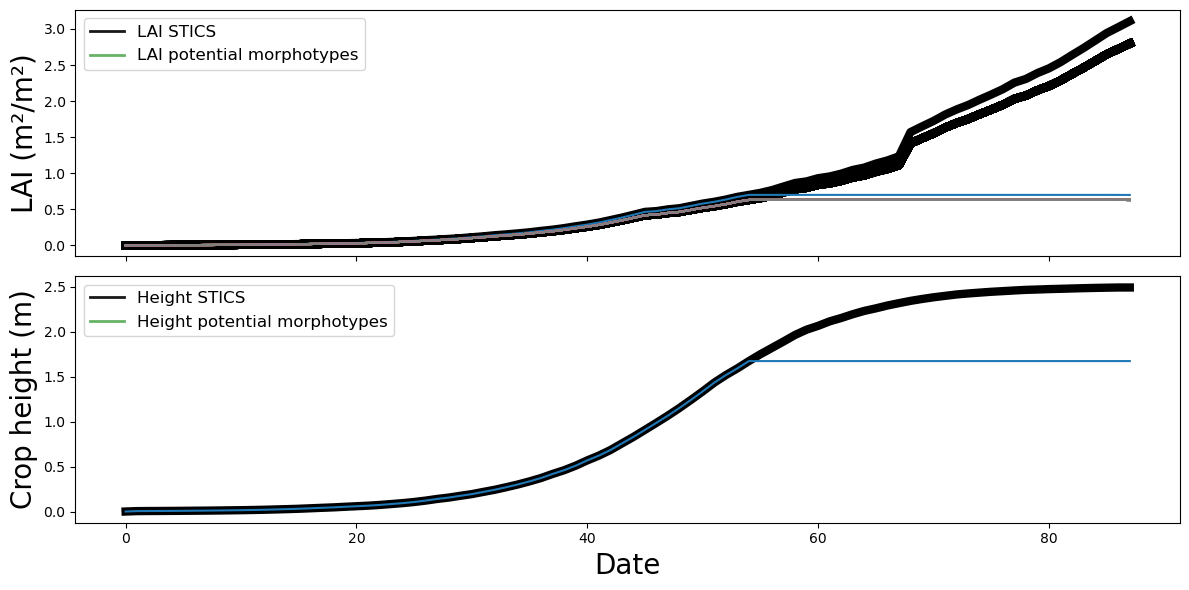

[0.000000e+00 3.200000e-02 5.760000e-01 1.264000e+00 2.208000e+00
 3.408000e+00 4.720000e+00 6.704000e+00 9.200000e+00 1.201600e+01
 1.606400e+01 2.123200e+01 2.921600e+01 3.854400e+01 4.950400e+01
 6.609600e+01 8.472000e+01 1.035040e+02 1.310880e+02 1.584160e+02
 1.882880e+02 2.306560e+02 2.858720e+02 3.475040e+02 4.269760e+02
 5.268000e+02 6.542560e+02 7.630080e+02 9.050400e+02 1.028272e+03
 1.181120e+03 1.327968e+03 1.496016e+03 1.668096e+03 1.853648e+03
 2.047488e+03 2.269984e+03 2.464880e+03 2.687360e+03 2.927744e+03
 3.134784e+03 3.362736e+03 3.645072e+03 3.882336e+03 4.125648e+03
 4.401008e+03 4.639568e+03 4.871584e+03 5.117024e+03 5.367232e+03
 5.609120e+03 5.790224e+03 5.938000e+03 6.080208e+03 6.177696e+03
 6.050240e+03 5.941504e+03 5.799456e+03 5.675136e+03 5.520912e+03
 5.372160e+03 5.201744e+03 5.027024e+03 4.837504e+03 4.638688e+03
 4.410528e+03 4.410528e+03 4.410528e+03 4.207536e+03 3.974736e+03
 3.718384e+03 3.492688e+03 3.242816e+03 2.960480e+03 2.960480e+03
 2.690032e

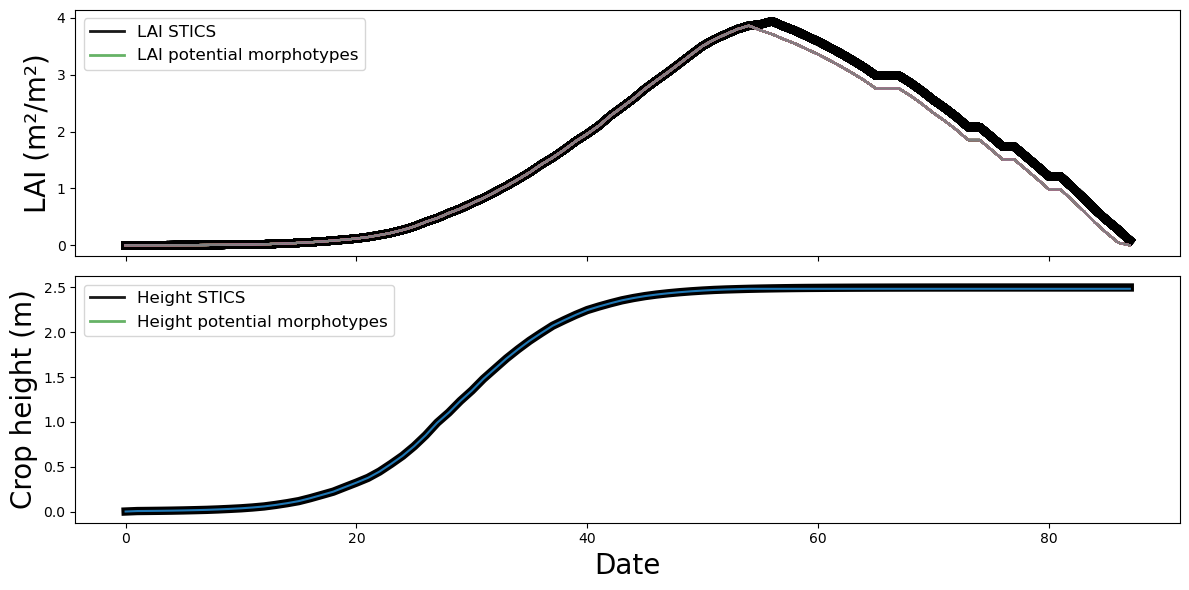

[0.0000000e+00 3.5600000e-02 6.5780000e-01 1.3689000e+00 2.2222000e+00
 3.1822000e+00 4.1066000e+00 5.3688000e+00 6.7910000e+00 8.2132000e+00
 1.0062100e+01 1.2177700e+01 1.5146600e+01 1.8186600e+01 2.1386600e+01
 2.5831000e+01 3.0275400e+01 3.4222100e+01 3.9715400e+01 4.4551000e+01
 4.9404300e+01 5.6035400e+01 6.4231000e+01 7.2728800e+01 8.3271000e+01
 9.6053200e+01 1.1201760e+02 1.2456870e+02 1.4124430e+02 1.5697760e+02
 1.7831090e+02 1.9905760e+02 2.2417760e+02 2.4366200e+02 2.6597310e+02
 2.9064870e+02 3.2135090e+02 3.4924420e+02 3.8412420e+02 4.2586640e+02
 4.6359080e+02 5.0895970e+02 5.6522640e+02 6.2211530e+02 6.8542200e+02
 7.5105760e+02 7.8559980e+02 8.5822200e+02 9.0391090e+02 9.8871090e+02
 1.0748442e+03 1.1389331e+03 1.2145953e+03 1.3038220e+03 1.3665420e+03
 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03
 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03
 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03
 1.366

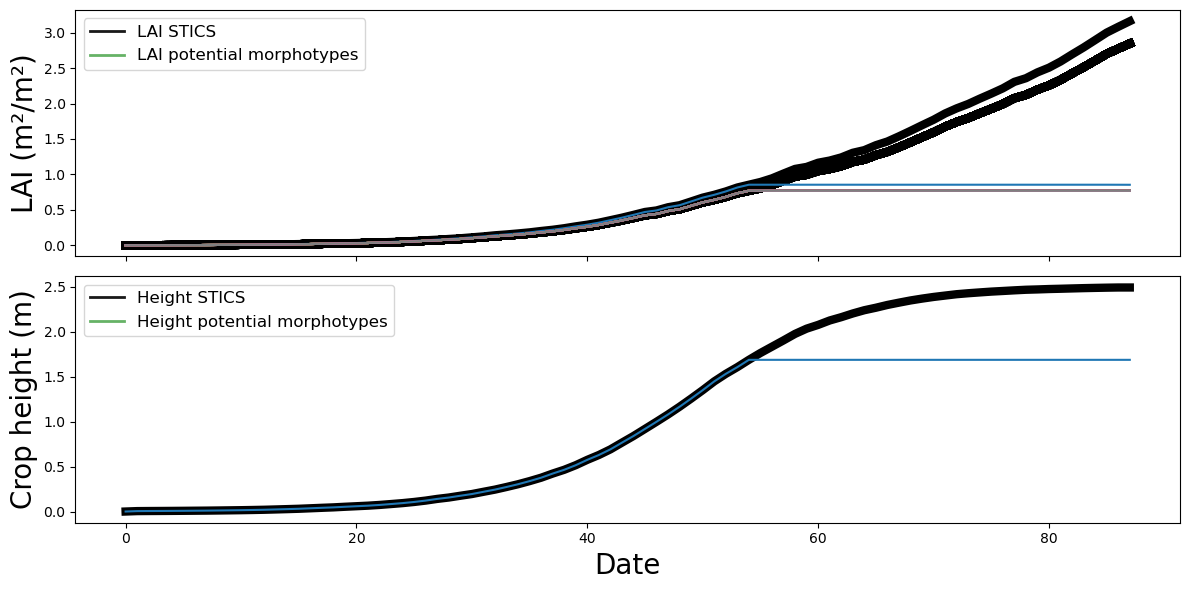

[0.000000e+00 3.200000e-02 5.760000e-01 1.264000e+00 2.208000e+00
 3.408000e+00 4.720000e+00 6.704000e+00 9.200000e+00 1.203200e+01
 1.608000e+01 2.124800e+01 2.920000e+01 3.851200e+01 4.945600e+01
 6.600000e+01 8.462400e+01 1.033920e+02 1.308320e+02 1.581120e+02
 1.879360e+02 2.299200e+02 2.849920e+02 3.464800e+02 4.250560e+02
 5.260960e+02 6.520480e+02 7.604800e+02 9.011680e+02 1.024048e+03
 1.175824e+03 1.321856e+03 1.488896e+03 1.659984e+03 1.844656e+03
 2.037728e+03 2.259424e+03 2.453936e+03 2.675616e+03 2.915488e+03
 3.122368e+03 3.350016e+03 3.631968e+03 3.869184e+03 4.149856e+03
 4.387968e+03 4.626480e+03 4.858848e+03 5.104704e+03 5.354960e+03
 5.597824e+03 5.779680e+03 5.928144e+03 6.072528e+03 6.168288e+03
 6.042352e+03 5.933904e+03 5.793232e+03 5.669248e+03 5.516096e+03
 5.368176e+03 5.198736e+03 5.025024e+03 4.836384e+03 4.638320e+03
 4.638320e+03 4.410960e+03 4.208368e+03 4.208368e+03 3.976336e+03
 3.720576e+03 3.495056e+03 3.245504e+03 2.963568e+03 2.963568e+03
 2.693264e

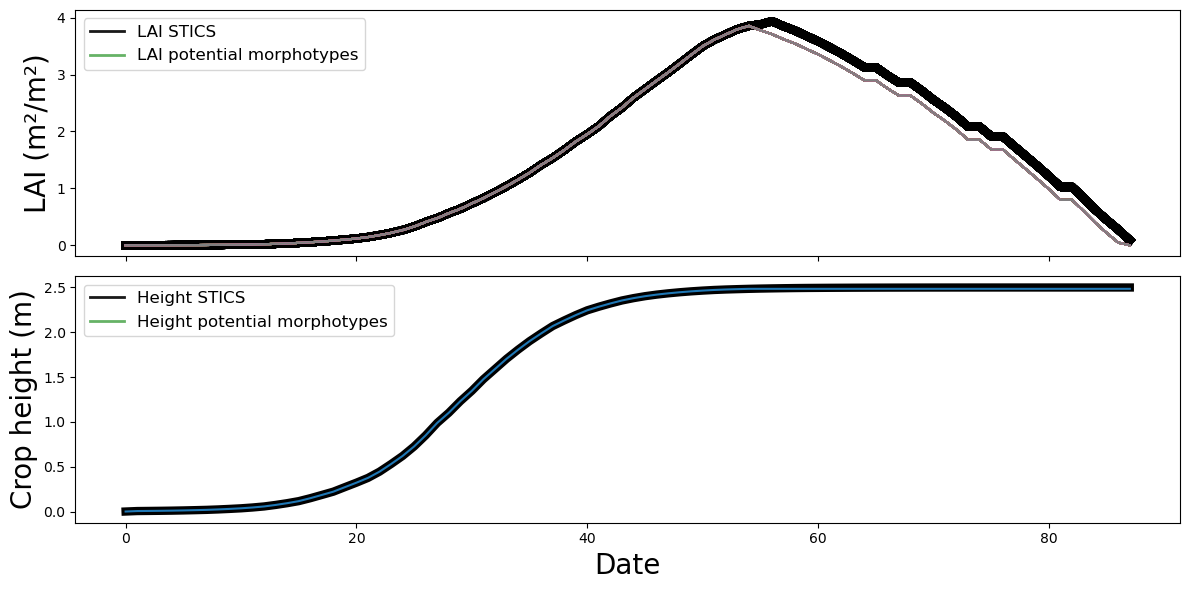

[0.000000e+00 3.560000e-02 6.578000e-01 1.368900e+00 2.222200e+00
 3.182200e+00 4.106600e+00 5.368800e+00 6.791000e+00 8.213200e+00
 1.006210e+01 1.217770e+01 1.512880e+01 1.818660e+01 2.136880e+01
 2.579550e+01 3.023990e+01 3.420430e+01 3.966210e+01 4.449770e+01
 4.933330e+01 5.589330e+01 6.407110e+01 7.255110e+01 8.296890e+01
 9.594670e+01 1.116800e+02 1.241956e+02 1.406756e+02 1.563734e+02
 1.774223e+02 1.979556e+02 2.227734e+02 2.420267e+02 2.641067e+02
 2.885156e+02 3.189156e+02 3.465956e+02 3.811378e+02 4.225245e+02
 4.600178e+02 5.050667e+02 5.609423e+02 6.175112e+02 6.805512e+02
 7.458845e+02 7.532267e+02 7.680356e+02 7.751289e+02 7.944178e+02
 8.115911e+02 8.220978e+02 8.354845e+02 8.526401e+02 8.619557e+02
 8.619557e+02 8.619557e+02 8.619557e+02 8.619557e+02 8.619557e+02
 8.619557e+02 8.619557e+02 8.619557e+02 8.619557e+02 8.619557e+02
 8.619557e+02 8.619557e+02 8.619557e+02 8.619557e+02 8.619557e+02
 8.619557e+02 8.619557e+02 8.619557e+02 8.619557e+02 8.619557e+02
 8.619557e

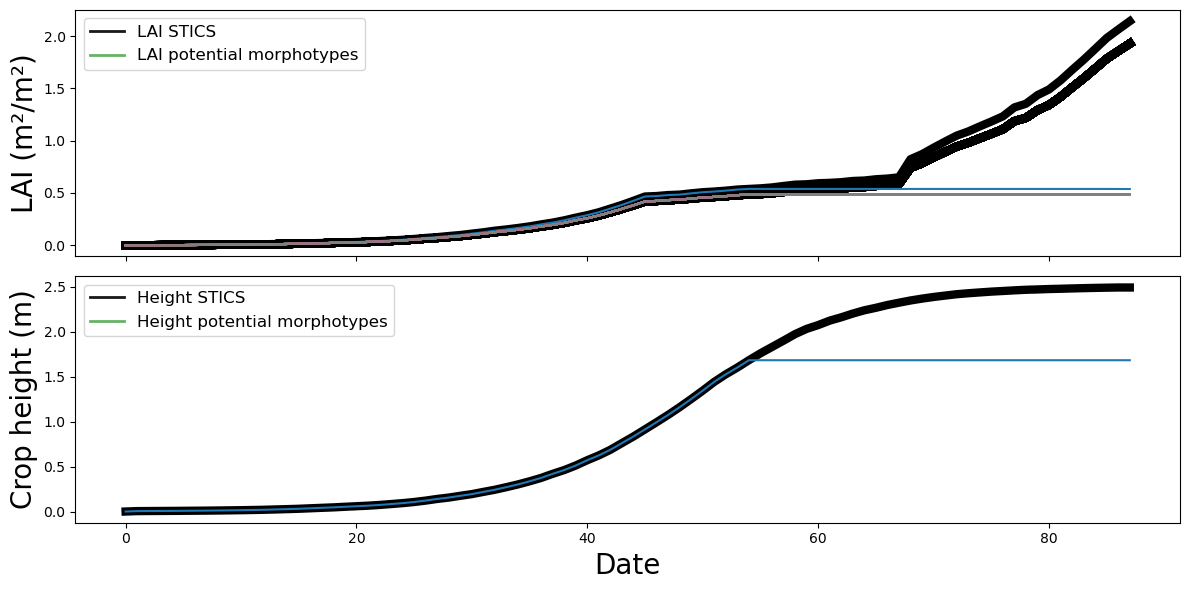

[0.000000e+00 3.200000e-02 5.760000e-01 1.264000e+00 2.208000e+00
 3.408000e+00 4.720000e+00 6.704000e+00 9.200000e+00 1.201600e+01
 1.606400e+01 2.123200e+01 2.921600e+01 3.854400e+01 4.950400e+01
 6.609600e+01 8.472000e+01 1.035040e+02 1.310880e+02 1.584160e+02
 1.882880e+02 2.306560e+02 2.858720e+02 3.475040e+02 4.269760e+02
 5.268000e+02 6.542560e+02 7.630080e+02 9.050400e+02 1.028272e+03
 1.181120e+03 1.327968e+03 1.496016e+03 1.668096e+03 1.853648e+03
 2.047488e+03 2.269984e+03 2.464880e+03 2.687360e+03 2.927744e+03
 3.134784e+03 3.362736e+03 3.645072e+03 3.882336e+03 4.125648e+03
 4.401008e+03 4.639568e+03 4.871584e+03 5.117024e+03 5.367232e+03
 5.609120e+03 5.790224e+03 5.938000e+03 6.080208e+03 6.177696e+03
 6.050240e+03 5.941504e+03 5.799456e+03 5.675136e+03 5.520912e+03
 5.372160e+03 5.201744e+03 5.027024e+03 4.837504e+03 4.638688e+03
 4.410528e+03 4.410528e+03 4.410528e+03 4.207536e+03 3.974736e+03
 3.718384e+03 3.492688e+03 3.242816e+03 2.960480e+03 2.960480e+03
 2.690032e

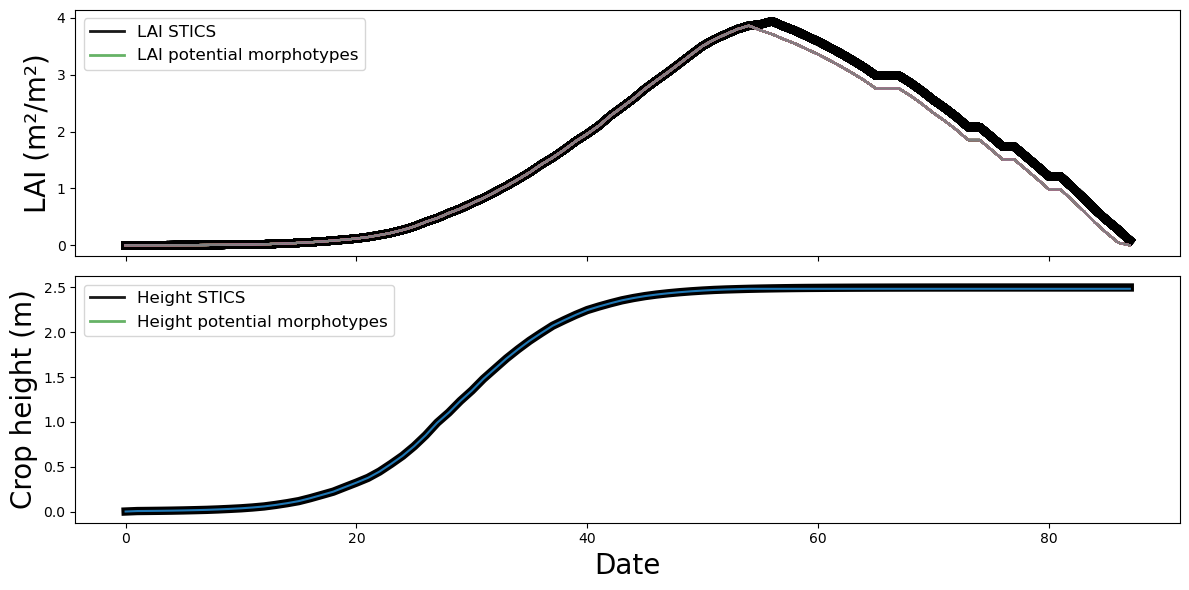

[0.0000000e+00 3.5600000e-02 6.5780000e-01 1.3689000e+00 2.2222000e+00
 3.1822000e+00 4.1066000e+00 5.3688000e+00 6.7910000e+00 8.2132000e+00
 1.0062100e+01 1.2177700e+01 1.5146600e+01 1.8186600e+01 2.1386600e+01
 2.5831000e+01 3.0275400e+01 3.4222100e+01 3.9715400e+01 4.4551000e+01
 4.9404300e+01 5.6035400e+01 6.4231000e+01 7.2728800e+01 8.3271000e+01
 9.6053200e+01 1.1201760e+02 1.2456870e+02 1.4124430e+02 1.5697760e+02
 1.7831090e+02 1.9905760e+02 2.2417760e+02 2.4366200e+02 2.6597310e+02
 2.9064870e+02 3.2135090e+02 3.4924420e+02 3.8412420e+02 4.2586640e+02
 4.6359080e+02 5.0895970e+02 5.6522640e+02 6.2211530e+02 6.8542200e+02
 7.5105760e+02 7.8559980e+02 8.5822200e+02 9.0391090e+02 9.8871090e+02
 1.0748442e+03 1.1389331e+03 1.2145953e+03 1.3038220e+03 1.3665420e+03
 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03
 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03
 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03
 1.366

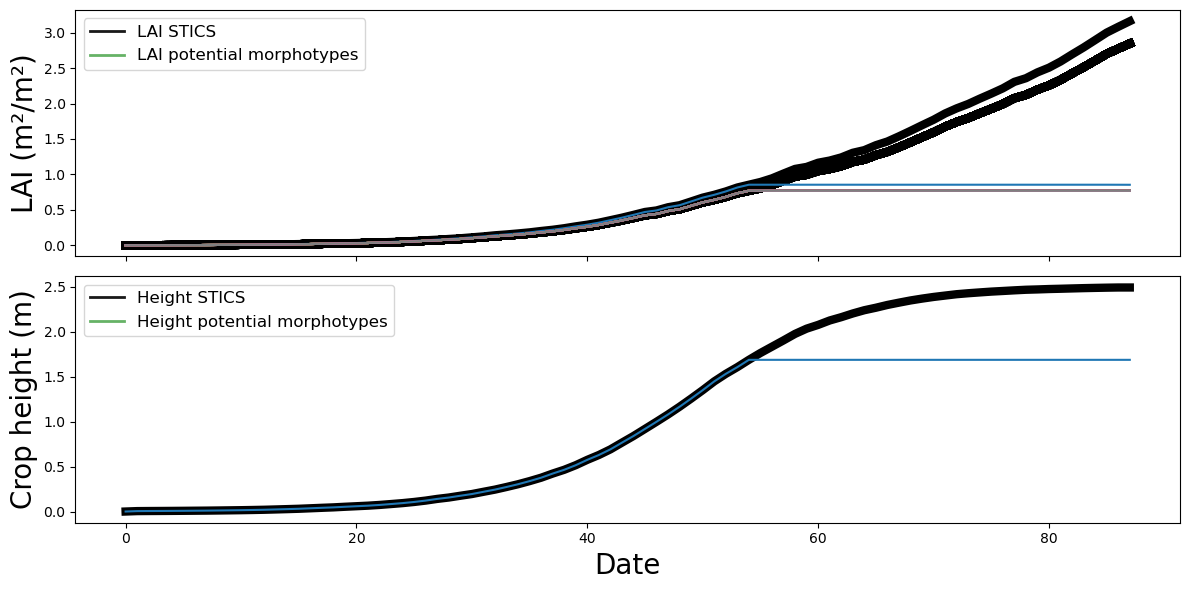

[0.000000e+00 3.200000e-02 5.760000e-01 1.264000e+00 2.208000e+00
 3.408000e+00 4.720000e+00 6.704000e+00 9.200000e+00 1.203200e+01
 1.608000e+01 2.124800e+01 2.920000e+01 3.851200e+01 4.945600e+01
 6.600000e+01 8.462400e+01 1.033920e+02 1.308320e+02 1.581120e+02
 1.879360e+02 2.299200e+02 2.849920e+02 3.464800e+02 4.250720e+02
 5.260960e+02 6.520800e+02 7.605280e+02 9.012160e+02 1.024096e+03
 1.175888e+03 1.321856e+03 1.488832e+03 1.659856e+03 1.844400e+03
 2.037312e+03 2.258832e+03 2.453136e+03 2.674640e+03 2.914272e+03
 3.120896e+03 3.348288e+03 3.629952e+03 3.866864e+03 4.147200e+03
 4.385008e+03 4.623232e+03 4.855296e+03 5.100848e+03 5.350832e+03
 5.593376e+03 5.774880e+03 5.923008e+03 6.067040e+03 6.162464e+03
 6.036480e+03 5.928048e+03 5.787360e+03 5.663376e+03 5.510208e+03
 5.362352e+03 5.192992e+03 5.019328e+03 4.830816e+03 4.632912e+03
 4.632912e+03 4.405744e+03 4.405744e+03 4.203344e+03 3.971488e+03
 3.715968e+03 3.490704e+03 3.241424e+03 2.959760e+03 2.959760e+03
 2.689760e

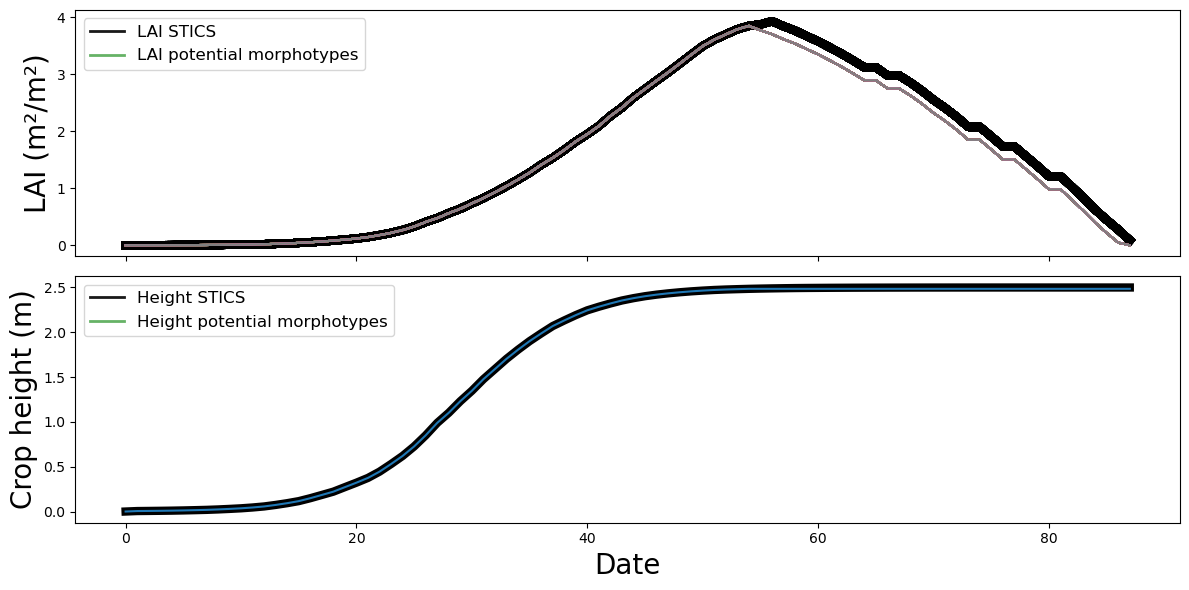

[0.000000e+00 3.560000e-02 6.578000e-01 1.368900e+00 2.222200e+00
 3.182200e+00 4.106600e+00 5.368800e+00 6.791000e+00 8.213200e+00
 1.006210e+01 1.217770e+01 1.512880e+01 1.818660e+01 2.136880e+01
 2.579550e+01 3.023990e+01 3.420430e+01 3.966210e+01 4.449770e+01
 4.933330e+01 5.589330e+01 6.407110e+01 7.255110e+01 8.296890e+01
 9.594670e+01 1.116978e+02 1.242134e+02 1.406934e+02 1.563734e+02
 1.774401e+02 1.979557e+02 2.227557e+02 2.420090e+02 2.640534e+02
 2.884445e+02 3.188267e+02 3.464711e+02 3.809600e+02 4.222933e+02
 4.597155e+02 5.046755e+02 5.604444e+02 6.169066e+02 6.798222e+02
 7.450311e+02 7.547200e+02 7.747378e+02 7.852978e+02 8.111822e+02
 8.348800e+02 8.506311e+02 8.701689e+02 8.945067e+02 9.092623e+02
 9.236623e+02 9.236623e+02 9.236623e+02 9.236623e+02 9.236623e+02
 9.236623e+02 9.236623e+02 9.236623e+02 9.236623e+02 9.236623e+02
 9.236623e+02 9.236623e+02 9.236623e+02 9.236623e+02 9.236623e+02
 9.236623e+02 9.236623e+02 9.236623e+02 9.236623e+02 9.236623e+02
 9.236623e

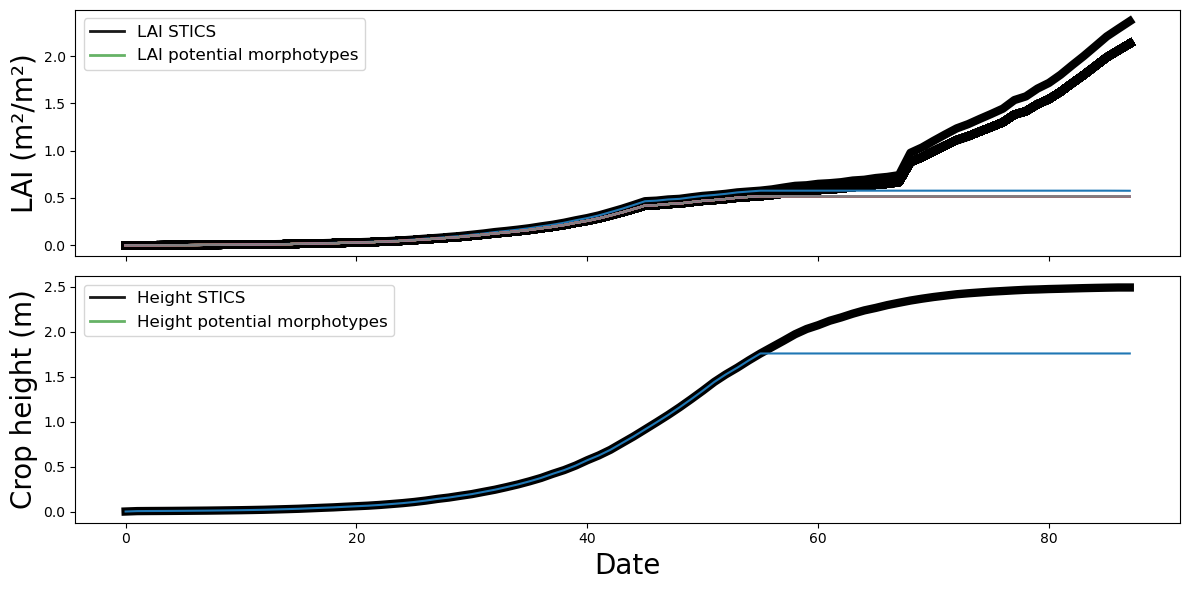

[0.000000e+00 3.200000e-02 5.760000e-01 1.264000e+00 2.208000e+00
 3.408000e+00 4.720000e+00 6.704000e+00 9.200000e+00 1.201600e+01
 1.606400e+01 2.123200e+01 2.921600e+01 3.854400e+01 4.950400e+01
 6.609600e+01 8.472000e+01 1.035040e+02 1.310880e+02 1.584160e+02
 1.882880e+02 2.306560e+02 2.858720e+02 3.475040e+02 4.269760e+02
 5.268000e+02 6.542560e+02 7.630080e+02 9.050400e+02 1.028272e+03
 1.181120e+03 1.327968e+03 1.496016e+03 1.668096e+03 1.853648e+03
 2.047488e+03 2.269984e+03 2.464880e+03 2.687360e+03 2.927744e+03
 3.134784e+03 3.362736e+03 3.645072e+03 3.882336e+03 4.125648e+03
 4.401008e+03 4.639568e+03 4.871584e+03 5.117024e+03 5.367232e+03
 5.609120e+03 5.790224e+03 5.938000e+03 6.080208e+03 6.177696e+03
 6.050240e+03 5.941504e+03 5.799456e+03 5.675136e+03 5.520912e+03
 5.372160e+03 5.201744e+03 5.027024e+03 4.837504e+03 4.638688e+03
 4.410528e+03 4.410528e+03 4.410528e+03 4.207536e+03 3.974736e+03
 3.718384e+03 3.492688e+03 3.242816e+03 2.960480e+03 2.960480e+03
 2.690032e

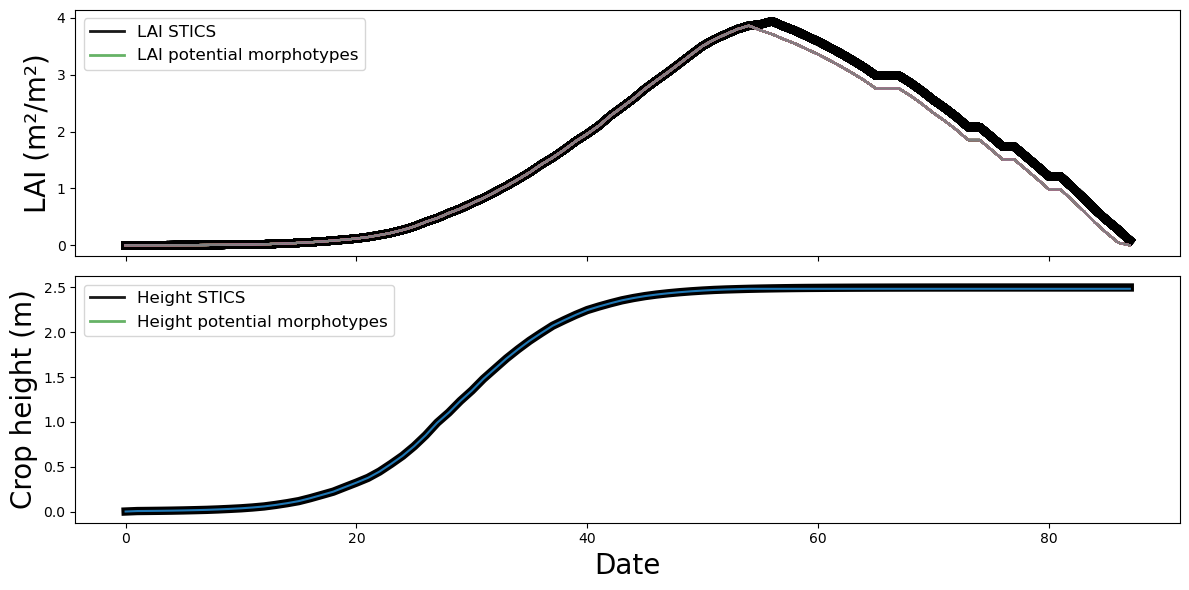

[0.0000000e+00 3.5600000e-02 6.5780000e-01 1.3689000e+00 2.2222000e+00
 3.1822000e+00 4.1066000e+00 5.3688000e+00 6.7910000e+00 8.2132000e+00
 1.0062100e+01 1.2177700e+01 1.5146600e+01 1.8186600e+01 2.1386600e+01
 2.5831000e+01 3.0275400e+01 3.4222100e+01 3.9715400e+01 4.4551000e+01
 4.9404300e+01 5.6035400e+01 6.4231000e+01 7.2728800e+01 8.3271000e+01
 9.6053200e+01 1.1201760e+02 1.2456870e+02 1.4124430e+02 1.5697760e+02
 1.7831090e+02 1.9905760e+02 2.2417760e+02 2.4366200e+02 2.6597310e+02
 2.9064870e+02 3.2135090e+02 3.4924420e+02 3.8412420e+02 4.2586640e+02
 4.6359080e+02 5.0895970e+02 5.6522640e+02 6.2211530e+02 6.8542200e+02
 7.5105760e+02 7.8559980e+02 8.5822200e+02 9.0391090e+02 9.8871090e+02
 1.0748442e+03 1.1389331e+03 1.2145953e+03 1.3038220e+03 1.3665420e+03
 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03
 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03
 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03 1.3665420e+03
 1.366

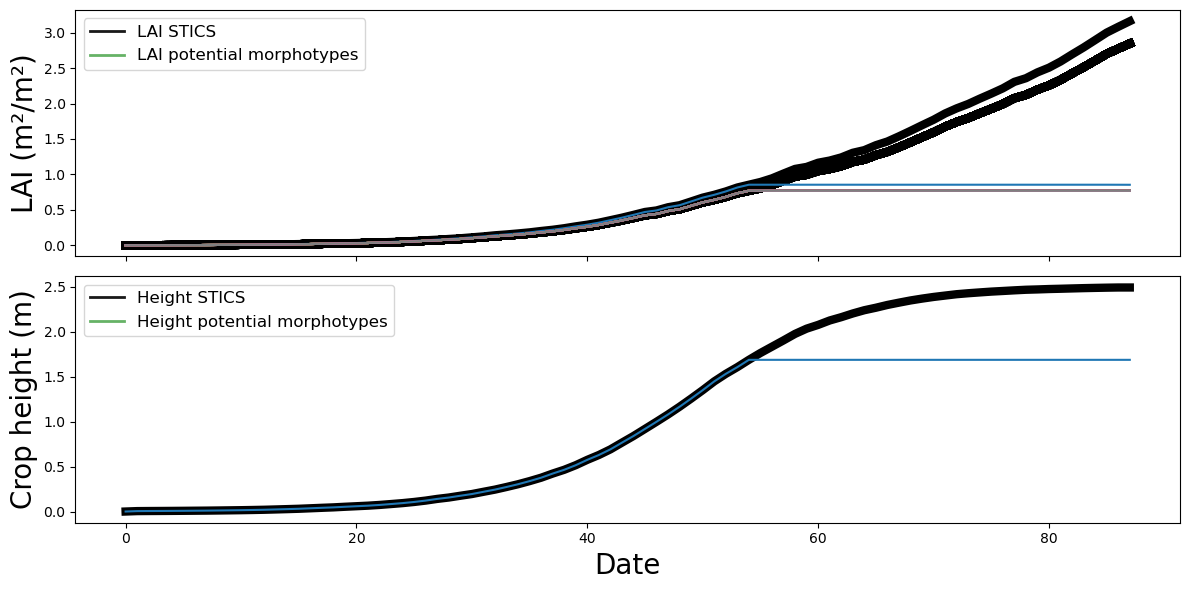

In [ ]:
def plot_constained_vs_realized_IC(dates, la, H, leaf_area_plant, height_canopy, sen_leaf_area_plant, density, stics_color="orange", archicrop_color="green"):
    
    # conversion factor
    cf_cm = 100

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)  # 1 row, 2 columns
    axes[0].plot(dates, [(la-sen)*density/cf_cm**2 for la, sen in zip(leaf_area_plant, sen_leaf_area_plant)], color=stics_color, linewidth=6)
    axes[0].plot(dates, [a*density/cf_cm**2 for a in la]) # , color=archicrop_color, alpha=0.6)
    # axes[0].set_xticks(np.arange(0, len(dates)+1, (len(dates)+1)/8))
    axes[0].set_ylabel("LAI (m²/m²)", fontsize=20)

    legend_elements_lai = [
        Line2D([0], [0], color=stics_color, alpha=0.9, lw=2, label='LAI STICS'),
        Line2D([0], [0], color=archicrop_color, alpha=0.6, lw=2, label='LAI potential morphotypes')
    ]
    axes[0].legend(handles=legend_elements_lai, loc=2, prop={'size': 12})

    axes[1].plot(dates, [h/cf_cm for h in height_canopy], color=stics_color, linewidth=6)
    axes[1].plot(dates, [h/cf_cm for h in H]) #, color=archicrop_color, alpha=0.6)
    # axes[1].set_xticks(np.arange(0, len(dates)+1, (len(dates)+1)/8))
    axes[1].set_xlabel("Date", fontsize=20)
    axes[1].set_ylabel("Crop height (m)", fontsize=20)

    legend_elements_height = [
        Line2D([0], [0], color=stics_color, alpha=0.9, lw=2, label='Height STICS'),
        Line2D([0], [0], color=archicrop_color, alpha=0.6, lw=2, label='Height potential morphotypes')
    ]
    axes[1].legend(handles=legend_elements_height, loc=2, prop={'size': 12})

    # Adjust layout
    plt.tight_layout()

    # Save figure
    # plt.savefig(f"../figures/plot_constrained_vs_realized_IC.png", dpi=1000)

    # Show the plot
    plt.show()

for u,usm in enumerate(usms_str):
    for a,algo in enumerate(algos):
        for p,plant in enumerate(plants):
            plot_constained_vs_realized_IC(dates, realized_la[usm][algo][plant], realized_h[usm][algo][plant], leaf_area_plant[usm][algo][plant], height_canopy[usm][algo][plant], sen_leaf_area_plant[usm][algo][plant], density[usm][algo][plant], stics_color="black")

In [11]:
# Energy in Caribu : MJ.day-1
# Irradiance in Caribu : MJ.m[leaf]-2.day-1
# Incident PAR in STICS : MJ.m[soil]-2.day-1
# Absorbed PAR in STICS : MJ.m[soil]-2.day-1

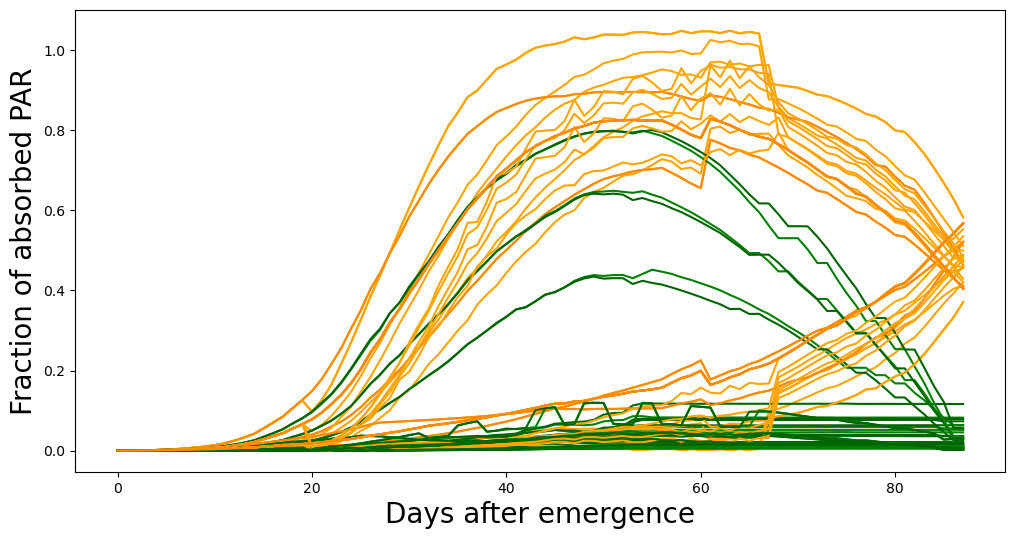

In [50]:
def plot_faPAR_algos_IC(dates, nrj_crop, par_stics):

    colors = {
        'STICS' : {'Beer': 'darkorange',
                   '2.5D': 'orange'},
        '3D' : {'Beer': 'darkgreen',
                '2.5D': 'green'}
    }

    # Plotting the envelope along with individual curves for context
    fig, ax = plt.subplots(figsize=(12, 6))
    for u,usm in nrj_crop.items():
        for a,algo in usm.items():
            for p,plant in algo.items():
                ax.plot(dates, plant, color=colors['3D'][a], label=f'3D {a}') #, color=archicrop_color, alpha=0.4, label="ArchiCrop x Caribu")
                ax.plot(dates, par_stics[u][a][p], color=colors['STICS'][a], label=f"STICS {a}")

    # Labels and legend
    # ax.set_xticks(np.arange(0, len(dates)+1, (len(dates)+1)/8))
    ax.set_xlabel("Days after emergence", fontsize=20) 
    ax.set_ylabel("Fraction of absorbed PAR", fontsize=20)
    # ax.legend()

    # Save figure
    plt.savefig(f"../figures/plot_faPAR_algos_IC.png", dpi=1000)

    plt.show()

plot_faPAR_algos_IC(dates, nrj_crop, par_stics)

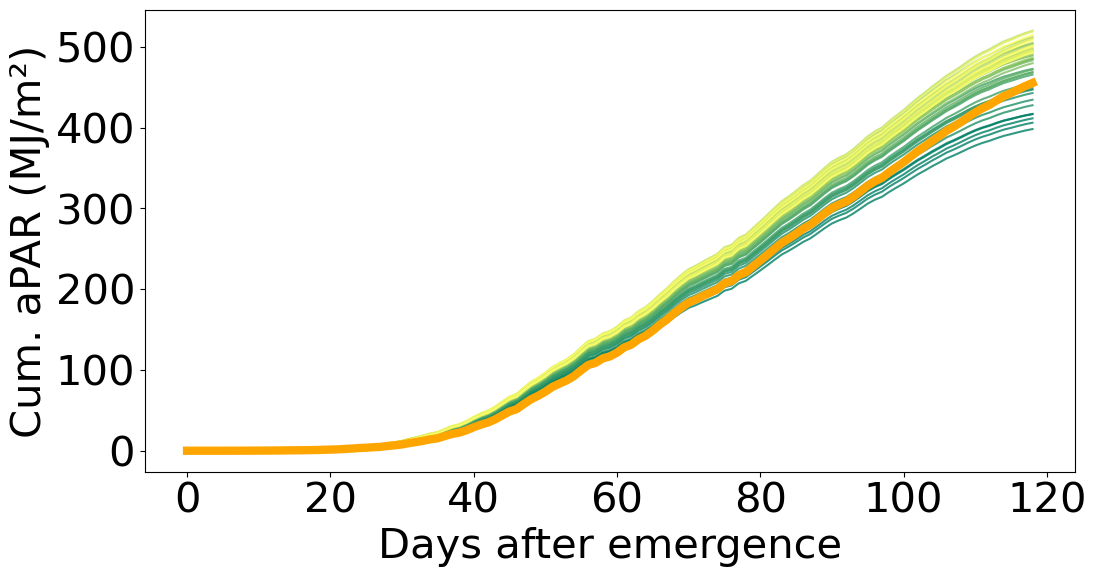

In [18]:
cumsum_nrj_per_plant(dates, nrj_crop, par_incident, par_stics, insertion_angle, 'insertion_angle', archicrop_color, stics_color='orange')

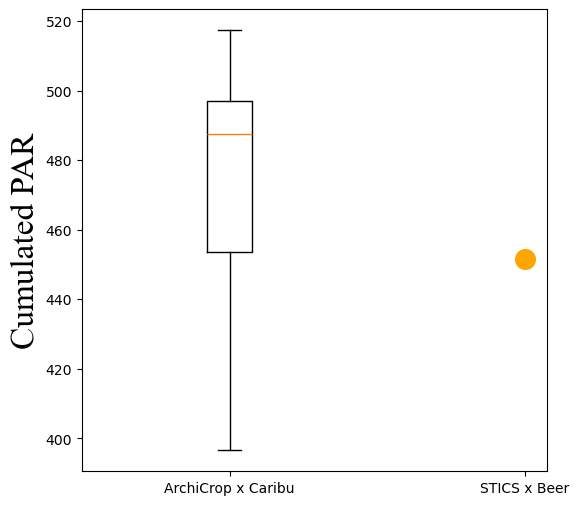

In [19]:
sum_nrj_per_plant(dates, nrj_crop, par_incident, par_stics, insertion_angle, 'insertion_angle', archicrop_color, stics_color='orange')

In [20]:
cf_cm = 100
lai = [la *density/cf_cm**2 for la in leaf_area_plant]

# plot_faPAR_per_leaf_parameter(lai, nrj_leaf, par_incident, par_stics, insertion_angle, 'insertion_angle', archicrop_color, stics_color='orange')

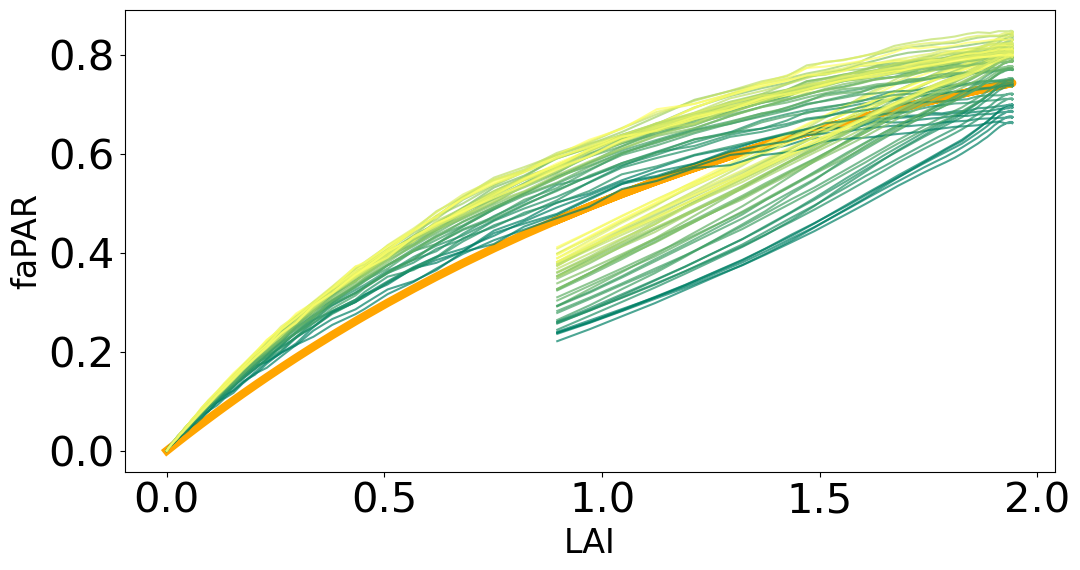

In [21]:
lai = [(la-sen)*density/cf_cm**2 for la, sen in zip(leaf_area_plant, sen_leaf_area_plant)]
plot_faPAR_lai_parameter(lai, nrj_crop, par_incident, par_stics, density, archi, insertion_angle, 'insertion_angle', archicrop_color, stics_color='orange')

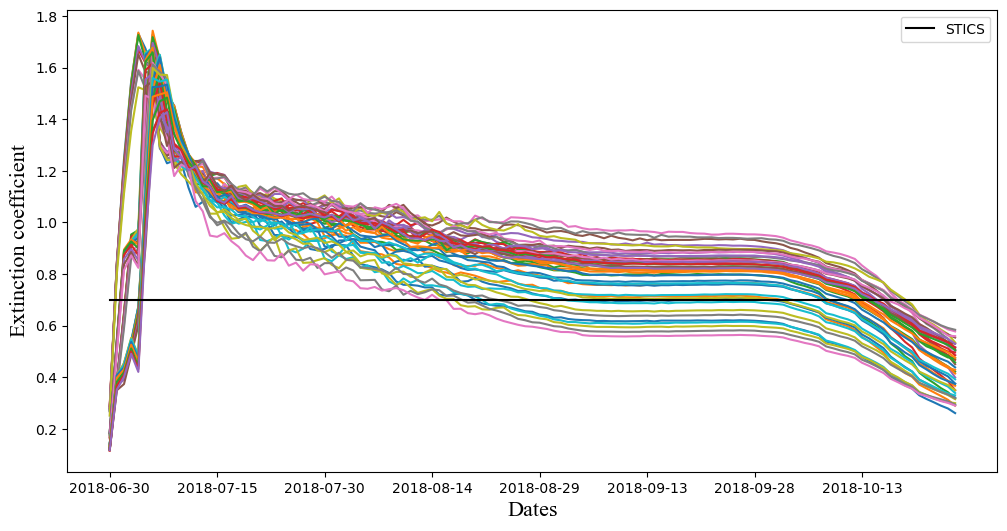

In [22]:
extinP_sorghum = 0.7

lai = [(la-sen)*density/cf_cm**2 for la, sen in zip(leaf_area_plant, sen_leaf_area_plant)]
extin_coefs = compute_extinction_coef(nrj_crop, par_incident, lai)
plot_extinction_coef(extinP_stics=extinP_sorghum, extin_coefs=extin_coefs, dates=dates)

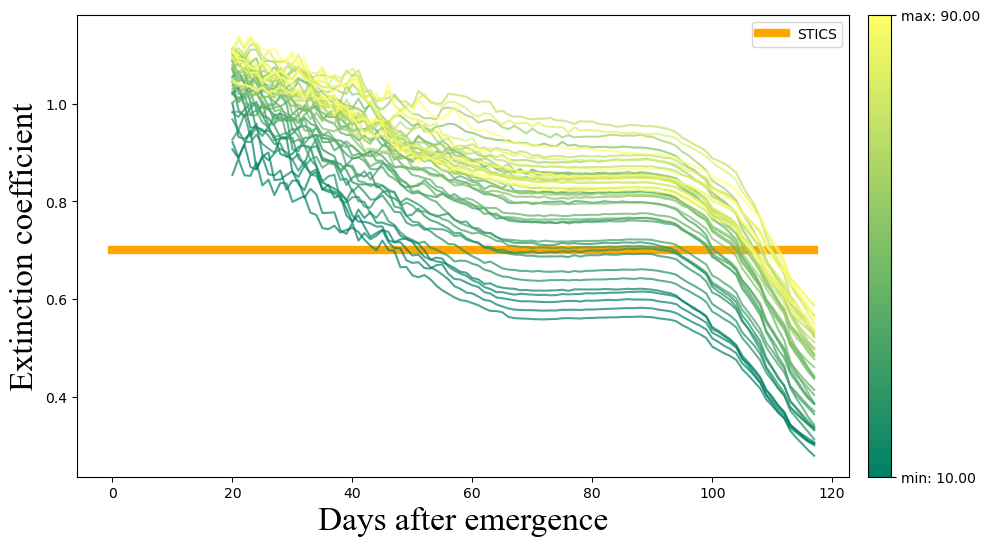

In [23]:
plot_extinction_coef_dyn_parameter(extinP_sorghum, extin_coefs, dates, nrj_crop, archi, insertion_angle, 'insertion_angle', archicrop_color, stics_color=stics_color)

In [24]:
theta=60
print(-0.000059*theta**2+ 0.0090*theta+ 0.55)

0.8775999999999999


k = -0.000059 theta^2 + 0.0090 theta + 0.55
R2 =  0.9036311345602013


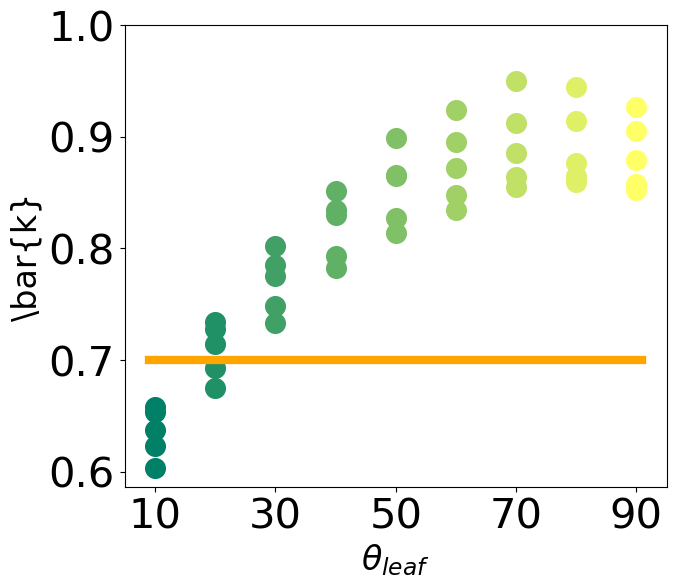

k = -0.0048 N + 0.9108
R2 =  0.0893644255465168


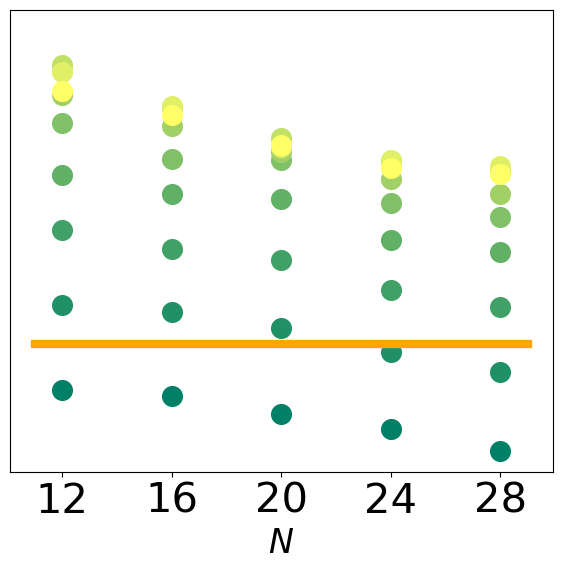

In [25]:
plot_extinction_coef_parameter(extinP_sorghum, extin_coefs, dates, nrj_crop, archi, insertion_angle, 'insertion_angle', insertion_angle, archicrop_color, stics_color=stics_color)
plot_extinction_coef_parameter(extinP_sorghum, extin_coefs, dates, nrj_crop, archi, nb_phy, 'nb_phy', insertion_angle, archicrop_color, stics_color=stics_color)

k = 0.5555 + 0.1263*log(theta) + -0.1205*LAIgreen + -0.9696*pLAIsen
R2 =  0.9384057705963413


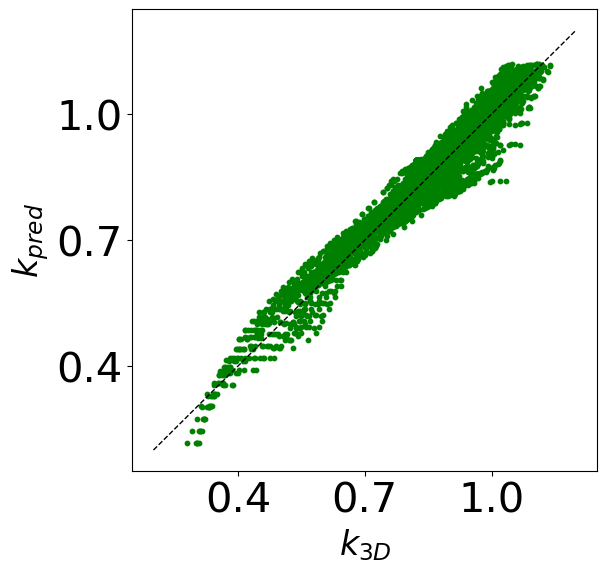

In [41]:
from sklearn.feature_selection import f_regression

start = 20
end = -1

L1 = len(extin_coefs.values())
lai_tot = np.array([la*density/cf_cm**2 for la in leaf_area_plant[start:end]]*L1)
lai_green = np.array([(la-sen)*density/cf_cm**2 for la, sen in zip(leaf_area_plant[start:end], sen_leaf_area_plant[start:end])]*L1)
# percent_green = np.array([green/tot for tot, green in zip(lai_tot, lai_green)])
percent_sen = np.array([1-green/tot for tot, green in zip(lai_tot, lai_green)])
L2 = len(leaf_area_plant[start:end])
theta = np.array(list(insertion_angle.values())).repeat(L2)
theta_log = np.array([math.log(x) for x in insertion_angle.values()]).repeat(L2)
nb = np.array(list(nb_phy.values())).repeat(L2)
k = np.array([ec[start:end] for ec in list(extin_coefs.values())]).flatten() # 2D array 

# print(len(theta_log), len(nb), len(lai_green), len(percent_green))

# X = np.column_stack((theta_log, nb, lai_green, percent_green))
X = np.column_stack((theta_log, lai_green, percent_sen))
# X = np.column_stack((theta_log, lai_green))
model = LinearRegression(fit_intercept=True).fit(X, k)
# model = f_regression(X, y)

# equation = f"k = {model.intercept_:.4f} + {model.coef_[0]:.4f}*log(theta) + {model.coef_[1]:.4f}*N + {model.coef_[2]:.4f}*LAIgreen + {model.coef_[3]:.4f}*pLAIgreen"
equation = f"k = {model.intercept_:.4f} + {model.coef_[0]:.4f}*log(theta) + {model.coef_[1]:.4f}*LAIgreen + {model.coef_[2]:.4f}*pLAIsen"
# equation = f"k = {model.intercept_:.4f} + {model.coef_[0]:.4f}*log(theta) + {model.coef_[1]:.4f}*LAIgreen"
print(equation)

fit_line = model.predict(X)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(k, fit_line, color="green", s=10)
ax.plot([0.2,1.2],[0.2,1.2], linestyle='dashed', color='black', linewidth=1)
ax.set_xlabel(r"$k_{3D}$", fontsize=24)
ax.set_ylabel(r"$k_{pred}$", fontsize=24)
ax.set_xticks([0.4,0.7,1.0])
ax.set_yticks([0.4,0.7,1.0])
ax.tick_params(axis='both', labelsize=30)

r2 = r2_score(k, fit_line)
# r2 = model.score()
print("R2 = ", r2)

# Save figure
today_str = date.today().strftime("%Y-%m-%d")
os.makedirs(f"../figures/", exist_ok=True)  
plt.savefig(f"../figures/plot_linear_model.png", dpi=1000)

# Export and reimport table with data

k = 0.5555 + 0.1263*log(theta) + -0.1205*LAIgreen + -0.9696*LAIgreen*pLAIsen
R2 =  0.9384057705963413


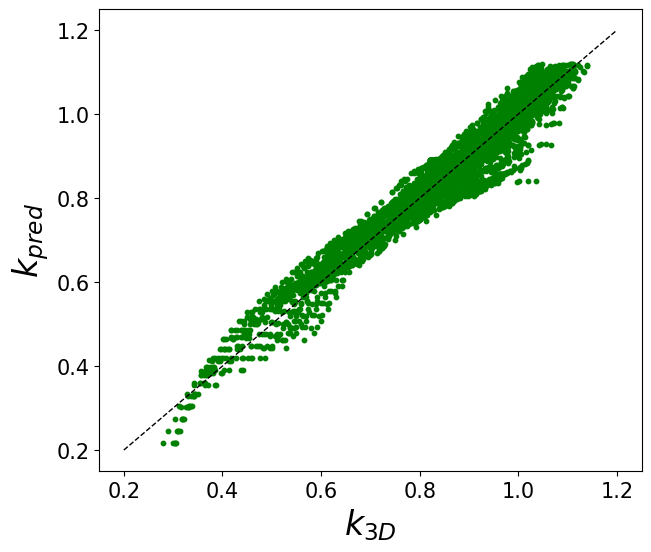

In [27]:
# theta = X[:,0]
theta_log = np.array([math.log(x) for x in theta])
L = X[:,1]
p = X[:,2]

# z = (L != 0).astype(float)  # conditional intercept
# X_model = np.column_stack([
#     z,
#     theta,
#     L,
#     p
# ])

# interaction = L * p

X_model = np.column_stack([
    theta_log,
    L,
    p,
    # interaction
])

model = LinearRegression(fit_intercept=True)
model.fit(X_model, k)

x0, x1, x2 = model.coef_

equation = f"k = {model.intercept_:.4f} + {x0:.4f}*log(theta) + {x1:.4f}*LAIgreen + {x2:.4f}*LAIgreen*pLAIsen"
# equation = f"k = {model.intercept_} + {x0:.4f}*log(theta) + {x1:.4f}*LAIgreen"
print(equation)

fit_line = model.predict(X_model)

r2 = r2_score(k, fit_line)
print("R2 = ", r2)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(k, fit_line, color="green", s=10)
ax.plot([0.2,1.2],[0.2,1.2], linestyle='dashed', color='black', linewidth=1)
ax.set_xlabel(r"$k_{3D}$", fontsize=24)
ax.set_ylabel(r"$k_{pred}$", fontsize=24)
ax.tick_params(axis='both', labelsize=15)

Text(0, 0.5, '$k_{pred}$')

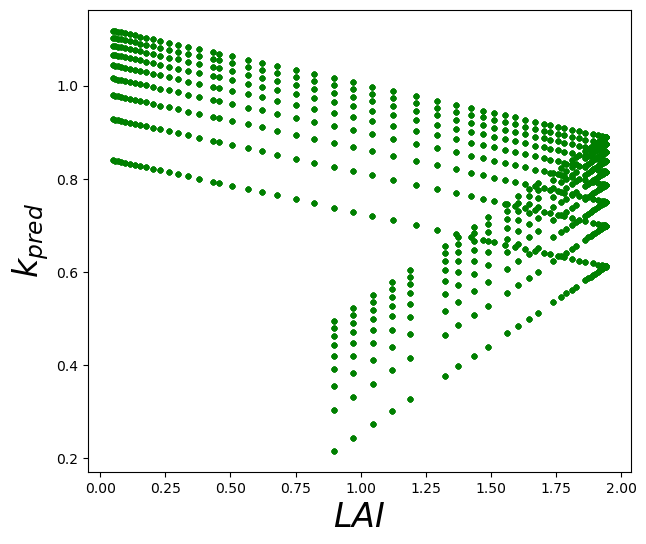

In [28]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(L, fit_line, color="green", s=10)
# ax.plot([0.2,1.2],[0.2,1.2], linestyle='dashed', color='black', linewidth=1)
ax.set_xlabel(r"$LAI$", fontsize=24)
ax.set_ylabel(r"$k_{pred}$", fontsize=24)

Text(0, 0.5, '$k_{pred}$')

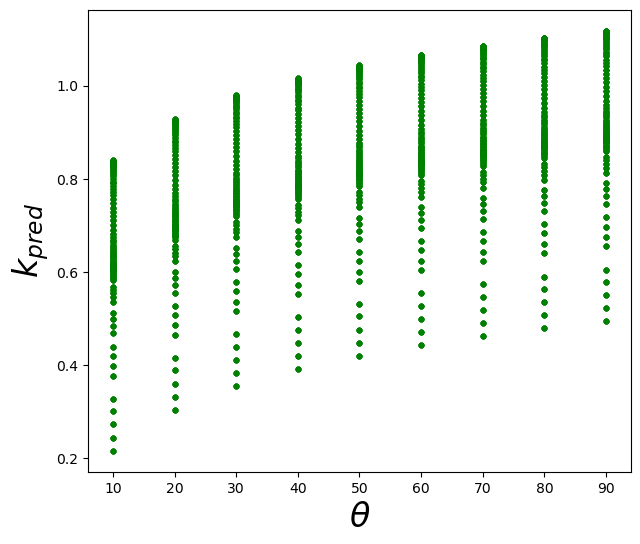

In [29]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(theta, fit_line, color="green", s=10)
# ax.plot([0.2,1.2],[0.2,1.2], linestyle='dashed', color='black', linewidth=1)
ax.set_xlabel(r"$\theta$", fontsize=24)
ax.set_ylabel(r"$k_{pred}$", fontsize=24)

In [30]:
from sklearn.feature_selection import f_regression

f, p = f_regression(X, k)

print(f)
print(p)

[1644.52469394 1106.87669393 3463.99481312]
[7.63368172e-306 9.80977664e-217 0.00000000e+000]


In [31]:
from scipy.stats import shapiro
residuals = k - fit_line
stat, p_value = shapiro(residuals)
print("Shapiro p-value:", p_value)

Shapiro p-value: 8.35567855482595e-27


In [32]:
# Residuals
residuals = k - fit_line
n = len(k)

# Number of parameters (coefficients + intercept)
p = len(X[0])+2

# Estimate variance (MLE version!)
sigma2 = np.sum(residuals**2) / n

# Log-likelihood under Gaussian errors
# log_likelihood = -n/2 * np.log(2 * np.pi * sigma2) - np.sum(residuals**2) / (2 * sigma2)
# log_likelihood = -n / 2 * np.log(2 * np.pi * sigma2) - (1 / (2 * sigma2)) * np.sum((y - predictions) ** 2)
log_likelihood = -n/2 * (np.log(2 * np.pi * sigma2) + 1)

# BIC
bic = -2 * log_likelihood + p * np.log(n)

print("BIC:", bic)

BIC: -15661.810991248032


In [33]:
# Residuals
n = len(k)
# residuals = [extinP_sorghum]*n - fit_line
residuals = k - [extinP_sorghum]*n

# Number of parameters (coefficients + intercept)
p = 1

# Estimate variance (MLE version!)
sigma2 = np.sum(residuals**2) / n

# Log-likelihood under Gaussian errors
log_likelihood = -n/2 * (np.log(2 * np.pi * sigma2) + 1)
# log_likelihood = -n/2 * np.log(2 * np.pi * sigma2) - np.sum(residuals**2) / (2 * sigma2)

# BIC
bic = -2 * log_likelihood + p * np.log(n)

print("BIC:", bic)

BIC: -1662.849164073462


In [34]:
# --- Compute residuals of each run vs fitted line ---
residuals = k - fit_line  # shape (n_runs, n_timesteps)
# Standard deviation across runs at each time step
std_residuals = residuals.std(axis=0)
# Compute residual sum of squares (RSS)
rss = np.sum(residuals**2)
# Number of data points
n = len(k)   
p = 6        

# BIC
bic = n * np.log(rss/n) + p * np.log(n)
print(f"BIC lm = {bic:.2f}")

BIC lm = -28168.46


In [35]:
# --- Compute residuals of each run vs fitted line ---
residuals = k - [extinP_sorghum]*len(k)  # shape (n_runs, n_timesteps)
# Standard deviation across runs at each time step
std_residuals = residuals.std(axis=0)
# Compute residual sum of squares (RSS)
rss = np.sum(residuals**2)
# Number of data points
n = len(k)   
p = 1        

# BIC
bic = n * np.log(rss/n) + p * np.log(n)
print(f"BIC const = {bic:.2f}")

BIC const = -14177.89


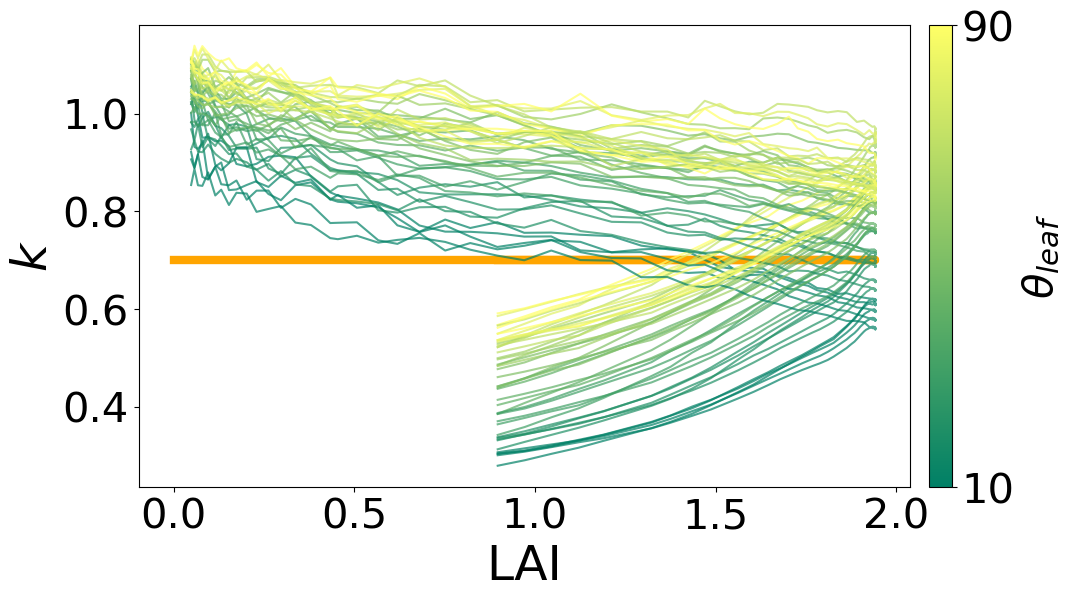

In [36]:
plot_extinction_coef_lai_parameter(extinP_sorghum, extin_coefs, lai, nrj_crop, archi, insertion_angle, 'insertion_angle', insertion_angle, archicrop_color, stics_color='orange')

k_growth = -0.120*LAI + 1.026
k_sen = 0.311*LAI + 0.143


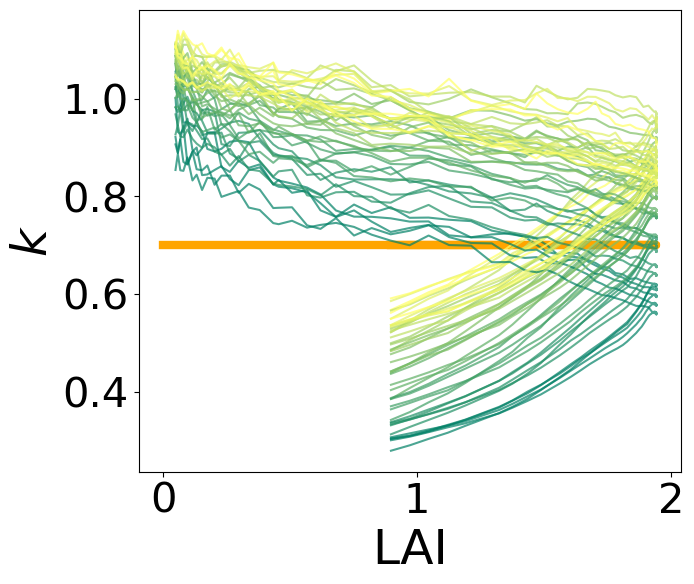

In [37]:
def plot_extinction_coef_lai_parameter(extinP_stics, extin_coefs, lai, nrj_crop, archi, parameter, parameter_name, insertion_angle, archicrop_color, stics_color):

    start = 20
    end = len(lai)-1 #34
    lai_trunc = lai[start:end]


    fig, ax = plt.subplots(figsize=(7, 6))
    # lai = [la*density/10000 for la in leaf_area_plant]
    # Normalize parameter values to [0, 1] for colormap
    param_values = np.array([parameter[k] for k in nrj_crop])
    norm = plt.Normalize(param_values.min(), param_values.max())
    cmap = plt.get_cmap('summer')
    # cmap = (mpl.colors.ListedColormap(['green', 'orange', '#BF864D']))
    # bounds = [param_values.min(), param_values.min()+(param_values.max()-param_values.min())/3, param_values.min()+2*(param_values.max()-param_values.min())/3, param_values.max()]
    # norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
    
    ax.plot(lai[:end], [extinP_stics]*len(lai[:end]), color=stics_color, linewidth=6, label="STICS")

    regressions = {}

    # Plot each curve with color from colormap
    for k,curve in extin_coefs.items():
        if parameter[k] in regressions:
            regressions[parameter[k]].append(curve[start:end])
        else:
            regressions[parameter[k]] = [curve[start:end]]
        color = cmap(norm(parameter[k]))
        ax.plot(lai[start:end], curve[start:end], color=color, alpha=0.7)

    t = 80
    slopes_growth = []
    slopes_sen = []
    intercepts_growth = []
    intercepts_sen = []
    
    for parameter_value, curves in regressions.items():
        mean_series = np.array(curves).mean(axis=0)
    
        model = LinearRegression().fit(np.array(lai_trunc[:t]).reshape(-1,1), mean_series[:t])
        slope = model.coef_[0]
        slopes_growth.append(slope)
        intercept = model.intercept_
        intercepts_growth.append(intercept)
        # equation = f"extinction coef = {slope:.3f}*LAI + {intercept:.3f}"
        # print(equation)
        # fit_line = model.predict(np.array(lai_trunc).reshape(-1,1))
    
        model = LinearRegression().fit(np.array(lai_trunc[t:]).reshape(-1,1), mean_series[t:])
        slope = model.coef_[0]
        slopes_sen.append(slope)
        intercept = model.intercept_
        intercepts_sen.append(intercept)
        # equation = f"extinction coef = {slope:.3f}*LAI + {intercept:.3f}"
        # print(equation)
        # fit_line = model.predict(np.array(lai_trunc).reshape(-1,1))
       
        # plt.plot([lai_trunc[0],lai_trunc[0]], [0,1.2], alpha=0.3, color="green")
        # plt.plot(lai_trunc, mean_series, color="black", linewidth=2, label="Mean series")
        # color = cmap(norm(parameter_value))
        # ax.plot(lai_trunc, fit_line, color='black', linewidth=3, linestyle="-")
        # ax.plot(lai_trunc, fit_line, color=color, linewidth=2, linestyle="--", label=f"Linear regression for {parameter_name}={parameter_value}")

    slope_growth_avg = np.mean(slopes_growth)
    intercept_growth_avg = np.mean(intercepts_growth)
    equation = f"k_growth = {slope_growth_avg:.3f}*LAI + {intercept_growth_avg:.3f}"
    print(equation)
    # fit_line = [slope_growth_avg*l+intercept_growth_avg for l in lai_trunc[:t]]
    # r2 = r2_score(k[:t], fit_line)
    # print("R2 = ", r2)
    slope_sen_avg = np.mean(slopes_sen)
    intercept_sen_avg = np.mean(intercepts_sen)
    equation = f"k_sen = {slope_sen_avg:.3f}*LAI + {intercept_sen_avg:.3f}"
    print(equation)
    # fit_line = [slope_sen_avg*l+intercept_sen_avg for l in lai_trunc[t:]]
    # r2 = r2_score(k[t:], fit_line)
    # print("R2 = ", r2)
    
    # ax.set_xticks(np.arange(0, len(dates)+1, (len(dates)+1)/8))
    ax.set_xlabel("LAI", fontsize=35) 
    ax.set_ylabel(r"$k$", fontsize=35)
    ax.set_xticks([0,1,2])
    ax.tick_params(axis='both', labelsize=30)
    # ax.set_title(f"Extinction coefficient as a function of {parameter_name}", fontsize=16, fontname="Times New Roman")

    # Add colorbar legend
    # sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    # sm.set_array([])
    # cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
    # cbar.set_label(r"$\theta_{leaf}$", fontsize=30)
    # cbar.set_ticks([param_values.min(), param_values.max()])
    # cbar.set_ticklabels([f"{param_values.min()}", f"{param_values.max()}"], fontsize=30)


    # ax.legend(fontsize=14)

    # Save figure
    today_str = date.today().strftime("%Y-%m-%d")
    os.makedirs(f"../figures/", exist_ok=True)  
    plt.savefig(f"../figures/plot_extin_coef_LAI_{parameter_name}.png", dpi=1000)

    plt.show()

plot_extinction_coef_lai_parameter(extinP_sorghum, extin_coefs, lai, nrj_crop, archi, insertion_angle, 'insertion_angle', insertion_angle, archicrop_color, stics_color='orange')

In [38]:
"""
# vertical light interception
cs, ei, df = illuminate(scene, scene_unit='cm')
cs.plot(ei)


# diffuse light interception
sources = skys.sky_sources()
cs, ei, df = illuminate(scene, light=sources, scene_unit='cm')
cs.plot(ei)

# get score per plant
def score(res):
    return pd.Series({'ei':(res.Ei*res.area).sum() / res.area.sum(),
                              'area': res.area.sum()})
df['nump']=nump
df.groupby('nump').apply(score)
"""

"\n# vertical light interception\ncs, ei, df = illuminate(scene, scene_unit='cm')\ncs.plot(ei)\n\n\n# diffuse light interception\nsources = skys.sky_sources()\ncs, ei, df = illuminate(scene, light=sources, scene_unit='cm')\ncs.plot(ei)\n\n# get score per plant\ndef score(res):\n    return pd.Series({'ei':(res.Ei*res.area).sum() / res.area.sum(),\n                              'area': res.area.sum()})\ndf['nump']=nump\ndf.groupby('nump').apply(score)\n"